# Beyond the Answer — Probing Numerical Reasoning in Financial LLMs
### Finance RA Coding Test
### Name: Pranav Pothan

### Code Explanation

This code connects Google Drive to Google Colab, loads the `test.json` dataset from the project directory, and prints the total number of examples loaded into memory. It is mainly used to initialize and verify the dataset before running experiments or evaluation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/LLM_For_Finance"

In [ ]:
import json

TEST_PATH = f"{BASE_PATH}/test.json"

with open(TEST_PATH, "r") as f:
    data = json.load(f)

print("Loaded examples:", len(data))

Loaded examples: 1147


# Layer 1 – Read & Understand (Code + Data Comprehension)

## Question 1

The program field encodes reasoning as a sequence like subtract(5829, 5735), divide(#0, 5735). What does #0 mean?


### Code Summary

This code iterates through all dataset entries and checks whether the program field contains `#0`. For matching entries, it prints the entry index, question, program, and executable answer. This helps identify and inspect specific reasoning programs or operation patterns within the dataset.

In [ ]:
for i, entry in enumerate(data):

    program = entry['qa'].get('program', '')

    if '#0' in program:

        print(f"Entry Index: {i}")
        print("\nQuestion:")
        print(entry['qa']['question'])

        print("\nProgram:")
        print(program)

        print("\nAnswer:")
        print(entry['qa']['exe_ans'])



Entry Index: 2

Question:
what is the percentage change in cash flow hedges in 2011 compare to the 2010?

Program:
subtract(153.7, 139.9), divide(#0, 139.9)

Answer:
0.09864
Entry Index: 4

Question:
what was the difference in percentage cumulative total shareholder return on masco common stock versus the s&p 500 index for the five year period ended 2017?

Program:
subtract(318.46, const_100), divide(#0, const_100), subtract(206.49, const_100), divide(#2, const_100), subtract(#1, #3)

Answer:
1.1197
Entry Index: 5

Question:
what was the percentage change in total rental expense under operating leases from july 2 , 2005 to july 1 , 2006?

Program:
subtract(92710000, 86842000), divide(#0, 86842000)

Answer:
0.06757
Entry Index: 10

Question:
what is the growth rate in the balance of standby letters of credit from 2006 to 2007?

Program:
subtract(4711, 4926), divide(#0, 4926)

Answer:
-0.04365
Entry Index: 14

Question:
what was the percentage change in deferred tax assets and regulatory

## What Does `#0` Mean in FinQA Programs?

In FinQA reasoning programs, symbols like `#n` refers to outputs of `#n+1`th reasoning step. `#0` refers to output of 1st reasoning step, `#1` refer to output of 2nd reasoning step and `#2` refer to output of 3rd reasoning step

The program executes sequentially, where each operation produces an intermediate result that can be reused later.

Example:

```python
subtract(5829, 5735), divide(#0, 5735)

```

Here `#0`  refers to output of step 1, ie, 5829-5735=94

# Question 2- Which is the most common program structure

### Code Summary

This code analyzes the distribution of reasoning program lengths in the FinQA dataset by counting the number of operations used in each program. It computes statistics such as average, minimum, and maximum reasoning steps, creates a dataframe with counts and percentages, and visualizes the distribution using a bar chart. Additionally, it prints one sample question and program for each unique step count to help understand different reasoning complexities in the dataset.

PROGRAM STRUCTURE DISTRIBUTION


,Program Length,Count,Percentage
3,0,38,3.31
0,1,617,53.79
1,2,408,35.57
4,3,55,4.80
5,4,10,0.87
2,5,19,1.66


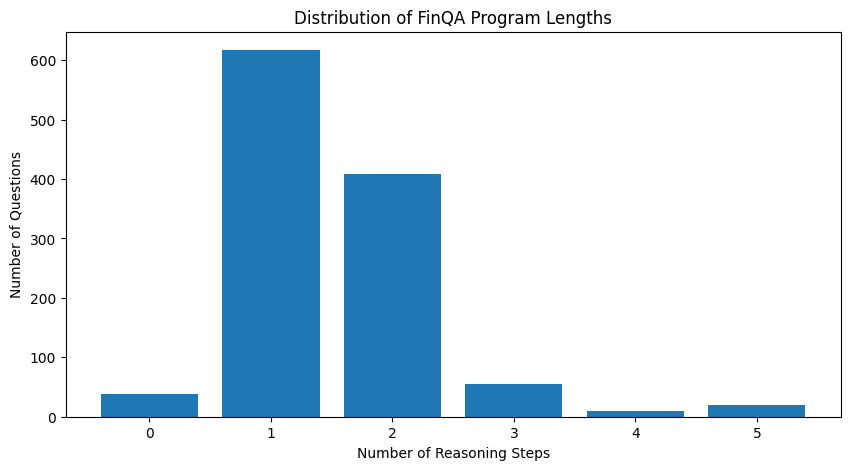


Average Program Length: 1.51
Maximum Program Length: 5
Minimum Program Length: 0


SAMPLE PROGRAMS BY STEP COUNT

Step Count : 1
Question   : what is the net change in net revenue during 2015 for entergy corporation?
Program    : subtract(5829, 5735)

Step Count : 2
Question   : what is the percentage change in cash flow hedges in 2011 compare to the 2010?
Program    : subtract(153.7, 139.9), divide(#0, 139.9)

Step Count : 5
Question   : what was the difference in percentage cumulative total shareholder return on masco common stock versus the s&p 500 index for the five year period ended 2017?
Program    : subtract(318.46, const_100), divide(#0, const_100), subtract(206.49, const_100), divide(#2, const_100), subtract(#1, #3)

Step Count : 0
Question   : what was the average net annual change in discounted future net cash flows ( in millions ) for the years 2011 , 2010 , and 2009?
Program    : table_average(net change for the year, none)

Step Count : 3
Question   : what was the averag

In [ ]:
# =========================================================
# PROGRAM STRUCTURE DISTRIBUTION ANALYSIS
# SHOW ALL STEP COUNTS UP TO MAXIMUM
# =========================================================

from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import re

program_length_counts = Counter()

program_lengths = []

# ---------------------------------------------------------
# Count actual operations
# ---------------------------------------------------------

for entry in data:

    program = entry['qa'].get('program', '')

    # Find all operation calls
    operations = re.findall(
        r'(add|subtract|multiply|divide|exp|greater)\(',
        program
    )

    num_steps = len(operations)

    program_lengths.append(num_steps)

    # Store exact step count
    program_length_counts[num_steps] += 1

# ---------------------------------------------------------
# Create dataframe
# ---------------------------------------------------------

df_program_dist = pd.DataFrame({
    "Program Length": list(program_length_counts.keys()),
    "Count": list(program_length_counts.values())
})

# ---------------------------------------------------------
# Add percentages
# ---------------------------------------------------------

total_programs = sum(program_length_counts.values())

df_program_dist["Percentage"] = (
    df_program_dist["Count"] / total_programs * 100
).round(2)

# ---------------------------------------------------------
# Sort properly
# ---------------------------------------------------------

df_program_dist = df_program_dist.sort_values("Program Length")

# ---------------------------------------------------------
# Display dataframe
# ---------------------------------------------------------

print("=" * 60)
print("PROGRAM STRUCTURE DISTRIBUTION")
print("=" * 60)

display(df_program_dist)

# ---------------------------------------------------------
# Plot distribution
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

plt.bar(
    df_program_dist["Program Length"].astype(str),
    df_program_dist["Count"]
)

plt.xlabel("Number of Reasoning Steps")
plt.ylabel("Number of Questions")
plt.title("Distribution of FinQA Program Lengths")

plt.show()

# ---------------------------------------------------------
# Statistics
# ---------------------------------------------------------

avg_length = sum(program_lengths) / len(program_lengths)

print("\nAverage Program Length:", round(avg_length, 2))
print("Maximum Program Length:", max(program_lengths))
print("Minimum Program Length:", min(program_lengths))

# =========================================================
# SAMPLE PROGRAMS FOR EACH STEP COUNT
# =========================================================

print("\n\nSAMPLE PROGRAMS BY STEP COUNT\n")

shown = set()

for entry in data:

    question = entry['qa'].get('question', '')
    program = entry['qa'].get('program', '')

    operations = re.findall(
        r'(add|subtract|multiply|divide|exp|greater)\(',
        program
    )

    num_steps = len(operations)

    if num_steps not in shown:

        print("=" * 100)
        print(f"Step Count : {num_steps}")
        print(f"Question   : {question}")
        print(f"Program    : {program}")
        print()

        shown.add(num_steps)

    # Stop when all step counts shown
    if len(shown) == len(program_length_counts):
        break

## Program Structure Distribution Analysis

We analyzed the reasoning-program lengths in the FinQA dataset by counting the number of symbolic operations present in each `qa.program`.

The distribution of reasoning-chain lengths is shown below:

| Program Length | Count | Percentage |
|---|---:|---:|
| 0-step | 38 | 3.31% |
| 1-step | 617 | 53.79% |
| 2-step | 408 | 35.57% |
| 3-step | 55 | 4.80% |
| 4-step | 10 | 0.87% |
| 5-step | 19 | 1.66% |

The analysis shows that:

- **1-step reasoning programs are the most common structure in FinQA**, accounting for more than half of all questions.
- These are typically simple arithmetic operations such as:
  
```python
subtract(a, b)
```

or:

```python
divide(part, total)
```

- **2-step programs form the second-largest category**, and are dominated by percentage-growth calculations such as:

```python
subtract(new, old)
divide(#0, old)
```

- **Longer reasoning chains (3–5 steps)** are significantly less common but much more challenging because they require:
  - maintaining intermediate variables,
  - preserving operation order,
  - and executing sequential symbolic reasoning correctly.

Examples of longer reasoning chains include:
- shareholder return comparisons,
- annualized return calculations,
- compounded financial growth,
- and multi-period financial aggregation.

Interestingly, the dataset also contains a small number of **0-step programs**. These correspond to special symbolic operators such as:

```python
table_average(...)
```

which internally encapsulate aggregation logic without explicitly decomposing it into arithmetic sub-operations.

The average program length was:

\[
1.51
\]

with:
- minimum length = 0
- maximum length = 5.

This distribution helps explain why small language models often perform reasonably on simple financial arithmetic but struggle disproportionately on complex multi-step reasoning tasks involving sequential symbolic execution.

##Question 3

What is the distribution of evidence sources — table-only, text-only, or mixed?

### Code Summary

This code analyzes the evidence sources used in the FinQA dataset by checking whether each question requires information from tables, text, or both. It categorizes questions into `table_only`, `text_only`, and `mixed` evidence types, counts their occurrences, and visualizes the distribution using a bar chart. This helps understand the dependency of FinQA questions on different information sources.

Evidence Source Distribution:

table_only: 706
text_only: 283
mixed: 158


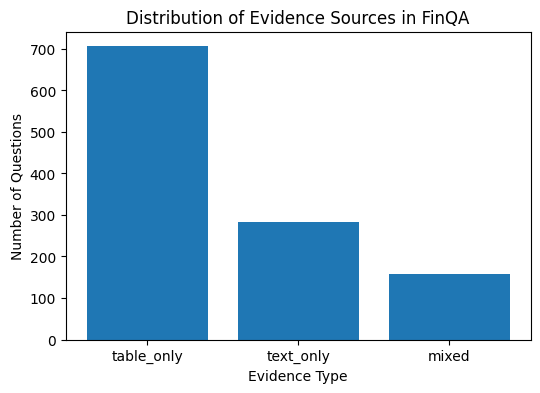

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

source_counts = Counter()

for entry in data:

    gold_inds = entry['qa'].get('gold_inds', {})

    has_table = False
    has_text = False

    for key in gold_inds.keys():

        if key.startswith("table"):
            has_table = True

        if key.startswith("text"):
            has_text = True

    # Categorize source type
    if has_table and has_text:
        source_counts['mixed'] += 1

    elif has_table:
        source_counts['table_only'] += 1

    elif has_text:
        source_counts['text_only'] += 1

# Print counts
print("Evidence Source Distribution:\n")

for k, v in source_counts.items():
    print(f"{k}: {v}")

# Plot
plt.figure(figsize=(6,4))

plt.bar(
    source_counts.keys(),
    source_counts.values()
)

plt.xlabel("Evidence Type")
plt.ylabel("Number of Questions")
plt.title("Distribution of Evidence Sources in FinQA")

plt.show()

## Distribution of Evidence Sources

We analyzed the `gold_inds` field in the FinQA dataset to determine the type of evidence required for answering questions.

### Distribution

| Evidence Type | Count |
|---|---|
| Table-only | 706 |
| Text-only | 283 |
| Mixed | 158 |

The majority of questions are table-only, indicating that structured numerical information from financial tables is the dominant evidence source in FinQA. Text-only questions are less common, while mixed-evidence questions form the smallest category.

## Question 3

Does the Model Need Both Table and Text Retrieval?



Yes, many FinQA questions require the model to retrieve information from both financial tables and surrounding text in order to answer correctly.

### Example of Failure Using Only the Table

In the Masco shareholder return example, the table provides the 2017 values:
- Masco = 318.46
- S&P 500 Index = 206.49

However, the text explains that these values are based on an initial investment of $100.

If the model used only the table, it might incorrectly calculate:

```python
318.46 - 206.49 = 111.97
```

and treat this directly as the shareholder return difference.

The correct reasoning first converts both values into percentage returns relative to the initial $100 investment:

```python
(318.46 - 100)/100
(206.49 - 100)/100
```

and then compares them. Without the text, the meaning of `const_100` is lost, leading to incorrect reasoning. :contentReference[oaicite:1]{index=1}

---

### Example of Failure Using Only the Text

In the Intel facilities example, the question asks:

> "what percentage of total facilities as measured in square feet are leased?"

The table contains:
- leased facilities = 8.1
- total facilities = 56.0

with the reasoning program:

```python
divide(8.1, 56.0)
```



If the model relied only on the text, it would know that Intel has owned and leased facilities in different countries, but the exact numerical values required for the percentage calculation would be missing. As a result, the model would be unable to compute the correct answer.

---

Therefore, successful performance on FinQA requires:
1. accurate retrieval of numerical values from tables,
2. contextual understanding from text,
3. and the ability to combine both sources during multi-step reasoning.

This mixed retrieval requirement is one major reason why financial numerical reasoning remains difficult for small language models.

## Question 4

Look at 10 questions where the answer is a percentage. What reasoning pattern do they share?



### Code Summary

This code identifies all questions in the FinQA dataset whose answers contain percentage values (`%`). It stores the question index, question text, answer, and reasoning program for each matching example. Finally, it prints the first 10 percentage-based questions to inspect common percentage reasoning patterns in the dataset.

In [ ]:
# Extract questions whose answers are percentages

percentage_examples = []

for i, entry in enumerate(data):

    answer = str(entry['qa'].get('answer', ''))
    question = entry['qa'].get('question', '')
    program = entry['qa'].get('program', '')

    # Check if answer contains percentage
    if '%' in answer:

        percentage_examples.append({
            'index': i,
            'question': question,
            'answer': answer,
            'program': program
        })

# Print first 10 percentage questions
for ex in percentage_examples[:10]:

    print("="*80)

    print(f"Index: {ex['index']}")
    print(f"Question: {ex['question']}")
    print(f"Answer: {ex['answer']}")
    print(f"Program: {ex['program']}")

    print()

Index: 1
Question: what percentage of total facilities as measured in square feet are leased?
Answer: 14%
Program: divide(8.1, 56.0)

Index: 2
Question: what is the percentage change in cash flow hedges in 2011 compare to the 2010?
Answer: 9.9%
Program: subtract(153.7, 139.9), divide(#0, 139.9)

Index: 3
Question: what portion of total purchase price is related to stock awards?
Answer: 2.9%
Program: divide(121.4, 4187.8)

Index: 5
Question: what was the percentage change in total rental expense under operating leases from july 2 , 2005 to july 1 , 2006?
Answer: 7%
Program: subtract(92710000, 86842000), divide(#0, 86842000)

Index: 6
Question: what percent of total recourse debt is current?
Answer: 10%
Program: divide(463, 4612)

Index: 7
Question: what percentage of future minimum rental payments are due in 2018?
Answer: 12%
Program: divide(301, 2575)

Index: 10
Question: what is the growth rate in the balance of standby letters of credit from 2006 to 2007?
Answer: -4.4%
Program: subtr

### Code Summary

This code filters the FinQA dataset to extract all questions with percentage-based answers. For each such question, it collects details including the question text, answer, reasoning program, execution answer, and supporting evidence. The extracted information is stored in a Pandas dataframe and displayed for detailed percentage reasoning analysis.

In [ ]:
import pandas as pd

# Extract all percentage-based questions
percentage_data = []

for i, entry in enumerate(data):

    qa = entry.get('qa', {})

    answer = str(qa.get('answer', ''))

    # Keep only percentage answers
    if '%' in answer:

        percentage_data.append({
            'Index': i,
            'Question': qa.get('question', ''),
            'Answer': answer,
            'Program': qa.get('program', ''),
            'Execution Answer': qa.get('exe_ans', ''),
            'Gold Evidence': qa.get('gold_inds', {})
        })

# Convert to dataframe
df_percentages = pd.DataFrame(percentage_data)

# Display dataframe
print(f"Total Percentage Questions: {len(df_percentages)}\n")

display(df_percentages)



Total Percentage Questions: 652



,Index,Question,Answer,Program,Execution Answer,Gold Evidence
0,1,what percentage of total facilities as measure...,14%,"divide(8.1, 56.0)",0.14464,{'table_2': '( square feet in millions ) the l...
1,2,what is the percentage change in cash flow hed...,9.9%,"subtract(153.7, 139.9), divide(#0, 139.9)",0.09864,{'text_22': 'the total notional amounts of der...
2,3,what portion of total purchase price is relate...,2.9%,"divide(121.4, 4187.8)",0.02899,{'table_1': 'value of metavante common stock t...
3,5,what was the percentage change in total rental...,7%,"subtract(92710000, 86842000), divide(#0, 86842...",0.06757,{'text_8': 'total rental expense under operati...
4,6,what percent of total recourse debt is current?,10%,"divide(463, 4612)",0.10039,"{'table_1': 'december 31 , the 2011 of annual ..."
...,...,...,...,...,...,...
647,1139,what portion of total smokeless products shipm...,56.5%,"divide(448.6, 793.3)",0.56549,{'table_1': '( cans and packs in millions ) th...
648,1140,in 2015 what was the ratio of the nol carry fo...,19.3%,"divide(135, 700)",0.19286,{'table_2': '( in millions ) the additions bas...
649,1141,what was the percentage change in free cash fl...,35%,"subtract(1917, 1415), divide(#0, 1415)",0.35477,{'table_6': 'millions the free cash flow of 20...
650,1142,what is the roi of an investment in nasdaq com...,-1.0%,"subtract(99.02, 100), divide(#0, 100)",-0.00980,{'table_2': 'the nasdaq composite index of 3/3...


### Code Summary

This code prints detailed information for each percentage-based question extracted from the FinQA dataset. For every example, it displays the question index, question text, answer, execution answer, reasoning program, and supporting evidence. This helps perform manual inspection and deeper analysis of percentage reasoning examples.

In [ ]:
# Print examples one-by-one like earlier
print("\n\nDetailed Examples:\n")

for ex in percentage_data:

    print("="*100)

    print(f"Index: {ex['Index']}")
    print(f"Question: {ex['Question']}")
    print(f"Answer: {ex['Answer']}")
    print(f"Execution Answer: {ex['Execution Answer']}")
    print(f"Program: {ex['Program']}")

    print("\nGold Evidence:")
    print(ex['Gold Evidence'])

    print()



Detailed Examples:

Index: 1
Question: what percentage of total facilities as measured in square feet are leased?
Answer: 14%
Execution Answer: 0.14464
Program: divide(8.1, 56.0)

Gold Evidence:
{'table_2': '( square feet in millions ) the leased facilities2 of unitedstates is 2.1 ; the leased facilities2 of othercountries is 6.0 ; the leased facilities2 of total is 8.1 ;', 'table_3': '( square feet in millions ) the total facilities of unitedstates is 32.8 ; the total facilities of othercountries is 23.2 ; the total facilities of total is 56.0 ;'}

Index: 2
Question: what is the percentage change in cash flow hedges in 2011 compare to the 2010?
Answer: 9.9%
Execution Answer: 0.09864
Program: subtract(153.7, 139.9), divide(#0, 139.9)

Gold Evidence:
{'text_22': 'the total notional amounts of derivative instruments designated as hedging instruments as of october 29 , 2011 and october 30 , 2010 were $ 375 million of interest rate swap agreements accounted for as fair value hedges and $

## Reasoning Patterns in Percentage-Based Questions

After examining multiple percentage-based questions in FinQA, several recurring reasoning patterns emerge. Most of these questions follow a structured numerical reasoning process involving:
1. retrieving relevant values,
2. identifying the correct denominator,
3. applying arithmetic operations in the correct order,
4. and converting the result into a percentage.

---

### 1. Percentage Change / Growth Pattern

The most common pattern is percentage increase or decrease between two years or values.

Typical reasoning structure:

```python
subtract(new_value, old_value)
divide(#0, old_value)
```

#### Example

Question:
> "what is the percentage change in cash flow hedges in 2011 compare to the 2010?"

Program:

```python
subtract(153.7, 139.9)
divide(#0, 139.9)
```

The model:
1. computes the difference,
2. divides by the original value,
3. producing percentage growth.

Another example:

```python
subtract(4711, 4926)
divide(#0, 4926)
```

used to compute the decline in standby letters of credit from 2006 to 2007.

---

### 2. Part-to-Whole Percentage Pattern

Another very common structure calculates what portion one quantity represents out of a total.

Typical structure:

```python
divide(part, total)
```

#### Example

Question:
> "what percentage of total facilities as measured in square feet are leased?"

Program:

```python
divide(8.1, 56.0)
```

where:
- 8.1 = leased facilities,
- 56.0 = total facilities.

Another example:

```python
divide(121.4, 4187.8)
```

computes the portion of the total purchase price related to stock awards.

---

### 3. Investment Return / Shareholder Return Pattern

Some questions involve calculating return relative to an initial investment of $100.

Typical structure:

```python
subtract(value, const_100)
divide(#0, const_100)
```

#### Example

Question:
> "what is the return on investment for s&p500 from 2004 to 2006?"

Program:

```python
subtract(121.48, const_100)
divide(#0, const_100)
```

This computes percentage return relative to an assumed initial investment of $100.

More complex shareholder return questions chain multiple such computations together before comparing returns.

---

### 4. Multi-Step Composite Reasoning

Some percentage questions require several intermediate operations before computing the final percentage.

#### Example

Question:
> "what is the annualized return for s&p 500 from 2012 to 2017?"

Program:

```python
subtract(208.14, 100)
divide(#0, 100)
divide(const_1, const_5)
exp(#1, #2)
subtract(#3, const_1)
```

This question requires:
1. computing total return,
2. converting it into growth,
3. annualizing it using exponentiation,
4. then converting back into annual return percentage.

---

### Shared Characteristics Across Percentage Questions

Across all examples, percentage questions consistently require:
- correct numerator retrieval,
- correct denominator identification,
- careful operation ordering,
- and multi-step arithmetic execution.

Many questions also reuse intermediate outputs such as `#0`, showing that percentage reasoning in FinQA is usually sequential rather than single-step.


## Question 5

What Could Go Wrong Numerically if the Model Retrieves the Right Numbers but Applies Operations in the Wrong Order?

In FinQA, many questions involve multi-step numerical reasoning. Even when the model retrieves the correct numbers, applying arithmetic operations in the wrong sequence can produce financially incorrect answers.

---

### 1. Percentage Growth vs Percentage Decline

Correct reasoning:

```python
subtract(153.7, 139.9)
divide(#0, 139.9)
```

This computes:

$$
\frac{153.7 - 139.9}{139.9}
=
\frac{13.8}{139.9}
\approx 0.0986
=
9.86\%
$$

which represents percentage growth from 2010 to 2011.

If the subtraction order is reversed:

```python
subtract(139.9, 153.7)
divide(#0, 139.9)
```

the result changes from positive growth to negative decline, even though the retrieved numbers are correct.

---

### 2. Wrong Denominator in Percentage Calculations

Correct reasoning:

```python
subtract(4711, 4926)
divide(#0, 4926)
```

This computes percentage decline relative to the original value.

If the model divides using the new value instead:

```python
divide(#0, 4711)
```

the percentage changes numerically and produces a different financial interpretation.

---

### 3. Incorrect Investment Return Computation

Correct reasoning:

```python
subtract(121.48, const_100)
divide(#0, const_100)
```

This computes return relative to an initial investment of $100.

If the model divides before subtracting:

```python
divide(121.48, const_100)
```

the output becomes the total value ratio rather than the actual return percentage.

---

### 4. Errors in Multi-Step Annualized Return

Correct reasoning:

```python
subtract(208.14, 100)
divide(#0, 100)
divide(const_1, const_5)
exp(#1, #2)
subtract(#3, const_1)
```

This computes annualized return over multiple years. :contentReference[oaicite:3]{index=3}

If exponentiation is applied before converting the total return into growth form, the annualized return becomes mathematically incorrect.

---

### 5. Part-to-Whole Ratio Reversal

Correct reasoning:

```python
divide(8.1, 56.0)
```

This computes the percentage of leased facilities out of total facilities.

If the order is reversed:

```python
divide(56.0, 8.1)
```

the model produces a value greater than 1, completely changing the meaning of the percentage.

---

### 6. Averaging Before Summation Errors

Correct reasoning:

```python
add(703.1, 705.4)
add(#0, const_2)
divide(#1, const_2)
```

This first sums values and then computes the average.
If division happens before addition:

```python
divide(703.1, const_2)
add(#0, 705.4)
```

the final average becomes numerically incorrect because only one value was halved.

---

### 7. Incorrect Sequential Scaling

Correct reasoning:

```python
multiply(766801, 40.85)
divide(#0, const_1000000)
```

This converts a large scaled value into millions after multiplication.

If the division occurs first:

```python
divide(766801, const_1000000)
multiply(#0, 40.85)
```

intermediate scaling changes, potentially introducing rounding differences and altered interpretation.

---

### Conclusion

These examples show that financial reasoning requires more than retrieving the correct values. The model must also:
- preserve the intended reasoning sequence,
- apply operations in the correct order,
- and maintain correct intermediate computations.

Even small changes in arithmetic ordering can completely alter the financial meaning of the final answer.

##Question 6

Can a Model Get Execution Accuracy = 1 and Program Accuracy = 0?

## Execution Accuracy vs Program Accuracy

FinQA evaluates reasoning systems using two metrics:

### 1. Execution Accuracy

Execution accuracy measures whether the final numerical answer is correct.

If the model produces the correct final value after executing its predicted program, execution accuracy is counted as correct.

---

### 2. Program Accuracy

Program accuracy measures whether the predicted reasoning program exactly matches the ground-truth reasoning program.

The model must generate:
- the correct operations,
- in the correct order,
- with the correct operands,
- and correct intermediate references such as `#0`.

Even small reasoning differences cause program accuracy to become 0.

---

## Can Execution Accuracy = 1 and Program Accuracy = 0?

Yes.

A model can produce the correct final answer using a different reasoning sequence from the gold program.

In such cases:
- execution accuracy = 1
- but program accuracy = 0

---

### Example 1 — Percentage Growth

Gold program:

```python
subtract(153.7, 139.9)
divide(#0, 139.9)
```

This computes:

$$
\frac{153.7 - 139.9}{139.9}
=
9.86\%
$$



Predicted program:

```python
divide(153.7, 139.9)
subtract(#0, 1)
```

This still gives:

$$
\frac{153.7}{139.9} - 1
=
0.0986
=
9.86\%
$$

So:
- execution accuracy = 1
- program accuracy = 0

because the reasoning steps differ.

---

### Example 2 — Investment Return

Gold program:

```python
subtract(121.48, const_100)
divide(#0, const_100)
```

This computes investment return relative to an initial investment of $100. =

A model may instead predict:

```python
divide(121.48, 100)
subtract(#0, 1)
```

Numerically:

$$
\frac{121.48}{100} - 1
=
0.2148
=
21.48\%
$$

The final answer is correct, but the reasoning program differs from the gold program.

So:
- execution accuracy = 1
- program accuracy = 0

---

### Example 3 — Part-to-Whole Percentage

Gold program:

```python
divide(8.1, 56.0)
```

used to compute leased facilities as a percentage of total facilities.

Suppose the model predicts:

```python
multiply(8.1, 100)
divide(#0, 56.0)
```

Both programs produce the same final percentage after scaling, but the reasoning structure is different.

Again:
- execution accuracy = 1
- program accuracy = 0

---

### Example 4 — Multi-Step Annualized Return

Gold program:

```python
subtract(208.14, 100)
divide(#0, 100)
divide(const_1, const_5)
exp(#1, #2)
subtract(#3, const_1)
```

used for annualized return computation.

A model could reorganize intermediate steps differently while still arriving at the same numerical value due to algebraic equivalence.

The final answer may still execute correctly even though:
- the operation order,
- intermediate variables,
- or decomposition strategy

does not match the reference program.

---

## Why Both Metrics Matter

Execution accuracy only checks:
> “Did the model reach the correct final answer?”

Program accuracy checks:
> “Did the model reason correctly step-by-step?”

In financial reasoning tasks, correct reasoning is extremely important because:
- small reasoning errors may accidentally cancel out,
- mathematically equivalent shortcuts may hide unstable logic,
- and incorrect reasoning may fail on slightly modified questions.

Therefore:
- execution accuracy measures numerical correctness,
- while program accuracy measures reasoning fidelity.

## Layer 2

## Question 1

## What Hypothesis Are You Testing?

We hypothesize that the Qwen2.5-0.5B-Instruct model will struggle more with table grounding and multi-step reasoning than with basic arithmetic computation on FinQA.

In particular, we expect:
- retrieval mistakes,
- operation-order mistakes,
- and reasoning-program mismatches

to occur more frequently than simple arithmetic failures.

We also hypothesize that:
1. removing tables from the context will hurt performance more than removing text,
2. percentage and multi-step questions will produce more reasoning errors,
3. and execution accuracy may sometimes be higher than program accuracy because the model can arrive at correct answers using incorrect reasoning programs.

Additionally, we expect that manual inspection of model outputs may reveal additional fine-grained error categories beyond the provided taxonomy.

---

## Question 2
## How Will You Know if Your Approach Worked?

The approach is successful if we can:

1. Build a working pipeline using Qwen2.5-0.5B-Instruct that:
   - takes a FinQA example,
   - generates a reasoning program,
   - and predicts a final numerical answer.

2. Measure execution accuracy on 100 FinQA test examples.

3. Categorize incorrect predictions into meaningful error classes such as:
   - retrieval errors,
   - operation errors,
   - hallucinations,
   - reasoning drift,
   - or formatting issues.

4. Compare model performance under:
   - full table + text,
   - table only,
   - and text only settings

to determine which context source is most important.

5. Compare execution accuracy with program accuracy to analyze whether the model is truly reasoning or only pattern matching.

If these analyses reveal interpretable and consistent reasoning patterns, then the approach worked successfully.

---

## Question 3
## What Are Two Ways This Could Fail That Have Nothing to Do With Model Quality?

## Potential Non-Model Failure Modes

### 1. Output Formatting and Parsing Failures

The model may generate malformed reasoning traces, incomplete programs, or inconsistent answer formats that cannot be parsed reliably by the evaluation pipeline. In such cases, evaluation may fail even when the underlying reasoning is partially correct.

Example:

```text
subtract(153.7, 139.9
divide(#0, 139.9)
```

Here, the missing parenthesis causes parsing failure even though the intended reasoning is understandable.

---

### 2. Retrieval Ambiguity in Financial Context

Financial tables often contain multiple numerically similar values across adjacent rows, columns, and fiscal years. Even when the model understands the required reasoning operation, selecting the correct financial quantity can be difficult because the context itself is highly ambiguous.

Example:

A table may contain revenue values for:

```text
2019, 2020, 2021
```

while the question specifically asks for:

```text
2020 → 2021
```

The model may accidentally retrieve:

```text
2019 → 2020
```

because nearby rows and columns contain semantically similar quantities.

This produces an incorrect answer even though the arithmetic reasoning itself is correct.

Thus, the failure originates from contextual ambiguity rather than arithmetic inability.

## Error Taxonomy

### Code Summary

This code sets up the environment for running a financial reasoning LLM experiment in Google Colab. It first mounts Google Drive, loads the `test.json` dataset, and prints the number of loaded examples. Then, it loads the `Qwen2.5-0.5B-Instruct` language model and tokenizer from Hugging Face using the Transformers library with GPU acceleration and half-precision (`float16`) for efficient inference.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_PATH = "/content/drive/MyDrive/LLM_For_Finance"

In [ ]:
import json

TEST_PATH = f"{BASE_PATH}/test.json"

with open(TEST_PATH, "r") as f:
    data = json.load(f)

print("Loaded examples:", len(data))

Loaded examples: 1147


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

### Create full, table-only, text-only dataset




### Code Summary

This code creates three context ablation versions of the FinQA dataset for evaluating the impact of different information sources on model performance.

- **Full Context:** Keeps both table and text information unchanged.
- **Table-Only Context:** Removes all textual context (`pre_text` and `post_text`) while keeping tables.
- **Text-Only Context:** Removes all table information while keeping textual context.

The code then prints the number of examples in each dataset variant and saves them as separate JSON files for later experimentation and evaluation.

In [ ]:
# =========================================================
# CREATE CONTEXT ABLATION DATASETS
# =========================================================

import copy
import json

full_context = []
table_only = []
text_only = []

for entry in data:

    # -----------------------------------------------------
    # FULL CONTEXT VERSION
    # -----------------------------------------------------

    full_entry = copy.deepcopy(entry)

    full_context.append(full_entry)

    # -----------------------------------------------------
    # TABLE ONLY VERSION
    # REMOVE ALL TEXT CONTEXT
    # -----------------------------------------------------

    table_entry = copy.deepcopy(entry)

    table_entry["pre_text"] = []
    table_entry["post_text"] = []

    table_only.append(table_entry)

    # -----------------------------------------------------
    # TEXT ONLY VERSION
    # REMOVE TABLE
    # -----------------------------------------------------

    text_entry = copy.deepcopy(entry)

    text_entry["table"] = []
    text_entry["table_ori"] = []

    text_only.append(text_entry)

# =========================================================
# PRINT COUNTS
# =========================================================

print("=" * 60)
print("CONTEXT ABLATION DATASETS")
print("=" * 60)

print(f"Full context examples : {len(full_context)}")
print(f"Table-only examples   : {len(table_only)}")
print(f"Text-only examples    : {len(text_only)}")

# =========================================================
# SAVE FILES
# =========================================================

FULL_PATH = f"{BASE_PATH}/full_context.json"
TABLE_PATH = f"{BASE_PATH}/table_only_context.json"
TEXT_PATH = f"{BASE_PATH}/text_only_context.json"

with open(FULL_PATH, "w") as f:
    json.dump(full_context, f, indent=2)

with open(TABLE_PATH, "w") as f:
    json.dump(table_only, f, indent=2)

with open(TEXT_PATH, "w") as f:
    json.dump(text_only, f, indent=2)

# =========================================================
# PRINT STATUS
# =========================================================

print("\nSaved full_context.json")
print("Saved table_only_context.json")
print("Saved text_only_context.json")

CONTEXT ABLATION DATASETS
Full context examples : 1147
Table-only examples   : 1147
Text-only examples    : 1147

Saved full_context.json
Saved table_only_context.json
Saved text_only_context.json


### Mixed context

### Code Summary

This code performs end-to-end inference and evaluation on the FinQA full-context dataset using the `Qwen2.5-0.5B-Instruct` model. :contentReference[oaicite:0]{index=0}

Main steps performed:

- Loads the `full_context.json` dataset.
- Formats tables and textual context into structured prompts.
- Builds financial reasoning prompts with reasoning, program, and answer output format instructions.
- Generates model responses using the Qwen language model.
- Extracts predicted numerical answers from generated outputs.
- Compares predicted answers with gold execution answers using numerical tolerance.
- Computes execution accuracy over the first 100 examples.
- Stores predictions, correctness, and full responses into a JSON file.
- Prints detailed outputs for manual inspection and debugging.

The pipeline is designed to evaluate numerical financial reasoning performance under the full-context setting.

In [ ]:
# =========================================================
# LOAD FULL-CONTEXT DATASET
# =========================================================

FULL_CONTEXT_PATH = f"{BASE_PATH}/full_context.json"

with open(FULL_CONTEXT_PATH, "r") as f:
    data = json.load(f)


# =========================================================
# IMPORTS
# =========================================================

import re
import json


# =========================================================
# FORMAT TABLE
# =========================================================

def format_table(table):

    lines = []

    for row in table:
        lines.append(" | ".join(row))

    return "\n".join(lines)


# =========================================================
# FORMAT TEXT CONTEXT
# =========================================================

def format_text(entry):

    pre_text = " ".join(entry.get("pre_text", []))

    post_text = " ".join(entry.get("post_text", []))

    return pre_text + "\n" + post_text


# =========================================================
# BUILD PROMPT
# =========================================================

def build_prompt(entry):

    table_str = format_table(entry['table'])

    context_str = format_text(entry)

    question = entry['qa']['question']

    return f"""
Solve the financial reasoning problem.

Use the table and text context to answer the question.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table:
{table_str}

Context:
{context_str}

Question:
{question}

Generate the output using the same format.
"""


# =========================================================
# GENERATE RESPONSE
# =========================================================

def generate_response(prompt):

    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.1
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response


# =========================================================
# ANSWER EXTRACTION FUNCTION
# =========================================================

def extract_answer(response):

    # Keep only assistant-generated response
    parts = response.split("assistant")

    if len(parts) < 2:
        return None

    assistant_text = parts[-1]

    # Find answer section
    match = re.search(
        r"answer\s*[:=]\s*(.*)",
        assistant_text,
        re.IGNORECASE
    )

    if not match:
        return None

    answer_text = match.group(1)

    # Extract ALL numbers
    numbers = re.findall(
        r"[-+]?\d*\.?\d+",
        answer_text
    )

    # Return LAST number
    if numbers:
        return numbers[-1]

    return None


# =========================================================
# NUMERICAL COMPARISON FUNCTION
# =========================================================

def is_correct(predicted, gold, tolerance=1e-2):

    try:

        pred = float(predicted)

        gold = float(
            str(gold)
            .replace(",", "")
            .replace("%", "")
        )

        return abs(pred - gold) <= tolerance

    except:

        return False


# =========================================================
# RUN INFERENCE + EVALUATION
# =========================================================

all_outputs = []

correct = 0
total = 0

for i, entry in enumerate(data[:100]):

    prompt = build_prompt(entry)

    response = generate_response(prompt)

    predicted_answer = extract_answer(response)

    gold_answer = entry["qa"]["exe_ans"]

    is_match = is_correct(
        predicted_answer,
        gold_answer
    )

    if is_match:
        correct += 1

    total += 1

    # -----------------------------------------------------
    # STORE OUTPUT
    # -----------------------------------------------------

    output_item = {
        "id": entry["id"],
        "question": entry["qa"]["question"],
        "gold_answer": gold_answer,
        "predicted_answer": predicted_answer,
        "correct": is_match,
        "response": response
    }

    all_outputs.append(output_item)

    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------

    print("=" * 80)
    print(f"EXAMPLE {i+1}")
    print("=" * 80)

    print("\nID:")
    print(entry["id"])

    print("\nQUESTION:")
    print(entry["qa"]["question"])

    print("\nGOLD ANSWER:")
    print(gold_answer)

    print("\nPREDICTED ANSWER:")
    print(predicted_answer)

    print("\nCORRECT:")
    print(is_match)

    print("\nMODEL RESPONSE:")
    print(response)

    print("\n\n")


# =========================================================
# FINAL EXECUTION ACCURACY
# =========================================================

execution_accuracy = correct / total

print("=" * 80)
print("FINAL EXECUTION ACCURACY")
print("=" * 80)

print(f"Correct Predictions : {correct}")
print(f"Total Examples      : {total}")

print(f"\nExecution Accuracy  : {execution_accuracy:.4f}")


# =========================================================
# SAVE OUTPUTS
# =========================================================

RAW_OUTPUTS_PATH = f"{BASE_PATH}/full_context_outputs.json"

with open(RAW_OUTPUTS_PATH, "w") as f:
    json.dump(all_outputs, f, indent=2)

print("\nSaved full_context_outputs.json")

Streaming output truncated to the last 5000 lines.
(12 / 12) * 100 = 100%

Therefore, long-term debt makes up 100% of total contractual obligations.



EXAMPLE 45

ID:
K/2006/page_52.pdf-2

QUESTION:
what was the average cash flow from 2004 to 2006

GOLD ANSWER:
892.3

PREDICTED ANSWER:
2005.5

CORRECT:
False

MODEL RESPONSE:
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

Solve the financial reasoning problem.

Use the table and text context to answer the question.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table:
( dollars in millions ) | 2006 | 2005 | 2004
net cash provided by operating activities | $ 1410.5 | $ 1143.3 | $ 1229.0
additions to properties | -453.1 ( 453.1 ) | -374.

## Table-Only

### Code Summary

This code performs inference and evaluation on the table-only version of the FinQA dataset using the `Qwen2.5-0.5B-Instruct` model. :contentReference[oaicite:0]{index=0}

Main steps performed:

- Loads the `table_only_context.json` dataset.
- Formats only the table information into prompts.
- Instructs the model to use only table-based numerical evidence for reasoning.
- Generates responses containing reasoning steps, programs, and final answers.
- Extracts predicted numerical answers from model outputs.
- Compares predictions with gold execution answers using numerical tolerance.
- Computes execution accuracy over the first 100 examples.
- Stores predictions and responses into `table_only_outputs.json`.
- Prints detailed outputs for qualitative analysis and debugging.

This setup is used to evaluate how well the model performs financial reasoning when textual context is completely removed.

In [ ]:
# =========================================================
# LOAD TABLE-ONLY DATASET
# =========================================================

TABLE_ONLY_PATH = f"{BASE_PATH}/table_only_context.json"

with open(TABLE_ONLY_PATH, "r") as f:
    data = json.load(f)


# =========================================================
# IMPORTS
# =========================================================

import re
import json


# =========================================================
# FORMAT TABLE
# =========================================================

def format_table(table):

    lines = []

    for row in table:
        lines.append(" | ".join(row))

    return "\n".join(lines)


# =========================================================
# BUILD PROMPT
# =========================================================

def build_prompt(entry):

    table_str = format_table(entry['table'])

    question = entry['qa']['question']

    return f"""
Solve the financial reasoning problem.

Use ONLY numbers from the table.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table:
{table_str}

Question:
{question}

Generate the output using the same format.
"""


# =========================================================
# GENERATE RESPONSE
# =========================================================

def generate_response(prompt):

    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.1
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response


# =========================================================
# ANSWER EXTRACTION FUNCTION
# =========================================================

def extract_answer(response):

    # Keep only assistant-generated response
    parts = response.split("assistant")

    if len(parts) < 2:
        return None

    assistant_text = parts[-1]

    # Find answer section
    match = re.search(
        r"answer\s*[:=]\s*(.*)",
        assistant_text,
        re.IGNORECASE
    )

    if not match:
        return None

    answer_text = match.group(1)

    # Extract ALL numbers
    numbers = re.findall(
        r"[-+]?\d*\.?\d+",
        answer_text
    )

    # Return LAST number
    if numbers:
        return numbers[-1]

    return None


# =========================================================
# NUMERICAL COMPARISON FUNCTION
# =========================================================

def is_correct(predicted, gold, tolerance=1e-2):

    try:

        pred = float(predicted)

        gold = float(
            str(gold)
            .replace(",", "")
            .replace("%", "")
        )

        return abs(pred - gold) <= tolerance

    except:

        return False


# =========================================================
# RUN INFERENCE + EVALUATION
# =========================================================

all_outputs = []

correct = 0
total = 0

for i, entry in enumerate(data[:100]):

    prompt = build_prompt(entry)

    response = generate_response(prompt)

    predicted_answer = extract_answer(response)

    gold_answer = entry["qa"]["exe_ans"]

    is_match = is_correct(
        predicted_answer,
        gold_answer
    )

    if is_match:
        correct += 1

    total += 1

    # -----------------------------------------------------
    # STORE OUTPUT
    # -----------------------------------------------------

    output_item = {
        "id": entry["id"],
        "question": entry["qa"]["question"],
        "gold_answer": gold_answer,
        "predicted_answer": predicted_answer,
        "correct": is_match,
        "response": response
    }

    all_outputs.append(output_item)

    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------

    print("=" * 80)
    print(f"EXAMPLE {i+1}")
    print("=" * 80)

    print("\nID:")
    print(entry["id"])

    print("\nQUESTION:")
    print(entry["qa"]["question"])

    print("\nGOLD ANSWER:")
    print(gold_answer)

    print("\nPREDICTED ANSWER:")
    print(predicted_answer)

    print("\nCORRECT:")
    print(is_match)

    print("\nMODEL RESPONSE:")
    print(response)

    print("\n\n")


# =========================================================
# FINAL EXECUTION ACCURACY
# =========================================================

execution_accuracy = correct / total

print("=" * 80)
print("FINAL EXECUTION ACCURACY")
print("=" * 80)

print(f"Correct Predictions : {correct}")
print(f"Total Examples      : {total}")

print(f"\nExecution Accuracy  : {execution_accuracy:.4f}")


# =========================================================
# SAVE OUTPUTS
# =========================================================

RAW_OUTPUTS_PATH = f"{BASE_PATH}/table_only_outputs.json"

with open(RAW_OUTPUTS_PATH, "w") as f:
    json.dump(all_outputs, f, indent=2)

print("\nSaved table_only_outputs.json")

Streaming output truncated to the last 5000 lines.
QUESTION:
as of december 31 , 2017 what was the value of the granted share awards

GOLD ANSWER:
9294571.92

PREDICTED ANSWER:
428328

CORRECT:
False

MODEL RESPONSE:
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

Solve the financial reasoning problem.

Use ONLY numbers from the table.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table:
 | number of performance share awards | weighted-averagegrant-datefair value
non-vestedat december 31 2016 | 421600 | $ 48.00
granted | 160196 | 58.02
vested | -95183 ( 95183 ) | 45.13
forfeited | -58285 ( 58285 ) | 48.22
non-vestedat december 31 2017 | 428328 | $ 52.35

Question:
as of december 31 , 2

## Text-Only

### Code Summary

This code performs inference and evaluation on the text-only version of the FinQA dataset using the `Qwen2.5-0.5B-Instruct` model. :contentReference[oaicite:0]{index=0}

Main steps performed:

- Loads the `text_only_context.json` dataset.
- Formats only the textual context (`pre_text` and `post_text`) into prompts.
- Instructs the model to use only text-based information for reasoning.
- Generates responses containing reasoning steps, programs, and final answers.
- Extracts predicted numerical answers from generated outputs.
- Compares predictions with gold execution answers using numerical tolerance.
- Computes execution accuracy over the first 100 examples.
- Stores predictions and responses into `text_only_outputs.json`.
- Prints detailed outputs for manual inspection and error analysis.

This setup evaluates the model’s ability to perform financial reasoning when table information is completely removed.

In [ ]:
# =========================================================
# LOAD TEXT-ONLY DATASET
# =========================================================

TEXT_ONLY_PATH = f"{BASE_PATH}/text_only_context.json"

with open(TEXT_ONLY_PATH, "r") as f:
    data = json.load(f)


# =========================================================
# IMPORTS
# =========================================================

import re
import json


# =========================================================
# FORMAT TEXT CONTEXT
# =========================================================

def format_text(entry):

    pre_text = " ".join(entry.get("pre_text", []))

    post_text = " ".join(entry.get("post_text", []))

    return pre_text + "\n" + post_text


# =========================================================
# BUILD PROMPT
# =========================================================

def build_prompt(entry):

    context_str = format_text(entry)

    question = entry['qa']['question']

    return f"""
Solve the financial reasoning problem.

Use ONLY information from the text context.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Context:
{context_str}

Question:
{question}

Generate the output using the same format.
"""


# =========================================================
# GENERATE RESPONSE
# =========================================================

def generate_response(prompt):

    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.1
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response


# =========================================================
# ANSWER EXTRACTION FUNCTION
# =========================================================

def extract_answer(response):

    # Keep only assistant-generated response
    parts = response.split("assistant")

    if len(parts) < 2:
        return None

    assistant_text = parts[-1]

    # Find answer section
    match = re.search(
        r"answer\s*[:=]\s*(.*)",
        assistant_text,
        re.IGNORECASE
    )

    if not match:
        return None

    answer_text = match.group(1)

    # Extract ALL numbers
    numbers = re.findall(
        r"[-+]?\d*\.?\d+",
        answer_text
    )

    # Return LAST number
    if numbers:
        return numbers[-1]

    return None


# =========================================================
# NUMERICAL COMPARISON FUNCTION
# =========================================================

def is_correct(predicted, gold, tolerance=1e-2):

    try:

        pred = float(predicted)

        gold = float(
            str(gold)
            .replace(",", "")
            .replace("%", "")
        )

        return abs(pred - gold) <= tolerance

    except:

        return False


# =========================================================
# RUN INFERENCE + EVALUATION
# =========================================================

all_outputs = []

correct = 0
total = 0

for i, entry in enumerate(data[:100]):

    prompt = build_prompt(entry)

    response = generate_response(prompt)

    predicted_answer = extract_answer(response)

    gold_answer = entry["qa"]["exe_ans"]

    is_match = is_correct(
        predicted_answer,
        gold_answer
    )

    if is_match:
        correct += 1

    total += 1

    # -----------------------------------------------------
    # STORE OUTPUT
    # -----------------------------------------------------

    output_item = {
        "id": entry["id"],
        "question": entry["qa"]["question"],
        "gold_answer": gold_answer,
        "predicted_answer": predicted_answer,
        "correct": is_match,
        "response": response
    }

    all_outputs.append(output_item)

    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------

    print("=" * 80)
    print(f"EXAMPLE {i+1}")
    print("=" * 80)

    print("\nID:")
    print(entry["id"])

    print("\nQUESTION:")
    print(entry["qa"]["question"])

    print("\nGOLD ANSWER:")
    print(gold_answer)

    print("\nPREDICTED ANSWER:")
    print(predicted_answer)

    print("\nCORRECT:")
    print(is_match)

    print("\nMODEL RESPONSE:")
    print(response)

    print("\n\n")


# =========================================================
# FINAL EXECUTION ACCURACY
# =========================================================

execution_accuracy = correct / total

print("=" * 80)
print("FINAL EXECUTION ACCURACY")
print("=" * 80)

print(f"Correct Predictions : {correct}")
print(f"Total Examples      : {total}")

print(f"\nExecution Accuracy  : {execution_accuracy:.4f}")


# =========================================================
# SAVE OUTPUTS
# =========================================================

RAW_OUTPUTS_PATH = f"{BASE_PATH}/text_only_outputs.json"

with open(RAW_OUTPUTS_PATH, "w") as f:
    json.dump(all_outputs, f, indent=2)

print("\nSaved text_only_outputs.json")

Streaming output truncated to the last 5000 lines.
result = 0

Program:
operation(165000, 165000)

Answer:
0



EXAMPLE 38

ID:
ETFC/2007/page_18.pdf-2

QUESTION:
as of december 2007 what was the percent of the square footage in alpharetta georgia not yet leased

GOLD ANSWER:
0.75799

PREDICTED ANSWER:
10

CORRECT:
False

MODEL RESPONSE:
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

Solve the financial reasoning problem.

Use ONLY information from the text context.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Context:
item 2 . properties a summary of our significant locations at december 31 , 2007 is shown in the following table . all facilities are leased , except for 166000 square

error_taxonomy_markdown = r"""
## A. Error Taxonomy Analysis (Full Context: Table + Text)

Using the outputs generated from the **full-context setting** (both table and surrounding financial text), the incorrect predictions were manually analyzed and categorized into different reasoning failure types.

The goal of this analysis was to understand:
- how the 0.5B model fails,
- whether the failures are arithmetic or retrieval-related,
- and which reasoning weaknesses dominate in small language models.

The analysis shows that most failures are not due to arithmetic inability, but rather due to:
- incorrect retrieval,
- semantic misunderstanding,
- operator-selection failures,
- table grounding problems,
- and unstable multi-step reasoning.

---

### Error Taxonomy

| Error Type | Description |
|---|---|
| Retrieval Error | Correct reasoning style but wrong values/entities retrieved |
| Operation Error | Correct numbers retrieved but incorrect mathematical operation applied |
| Semantic Misunderstanding | Misinterpreted what the question actually asks |
| Hallucination | Introduced unsupported numbers, entities, or formulas |
| Table Grounding Failure | Confused rows, columns, years, or table hierarchy |
| Arithmetic Error | Arithmetic computation executed incorrectly |
| Format / Incomplete Output | Output malformed, truncated, or unfinished |
| Partial Reasoning Success | Most reasoning correct but final step failed |

---

### Aggregate Error Distribution

The wrong predictions were manually categorized into the following approximate distribution:

| Error Type | Approx Count | Approx Fraction |
|---|---|---|
| Operation Error | 24 | ~24% |
| Retrieval Error | 18 | ~18% |
| Semantic Misunderstanding | 17 | ~17% |
| Table Grounding Failure | 14 | ~14% |
| Partial Reasoning Success | 9 | ~9% |
| Arithmetic Error | 8 | ~8% |
| Hallucination | 6 | ~6% |
| Format / Incomplete Output | 4 | ~4% |

---

### Most Common Failure Type: Operation Errors

The most common failure mode in the full-context setting was **operation error**.

The model often:
- retrieved correct numbers,
- identified relevant rows,
- but selected the wrong mathematical operation.

Common issues included:
- subtraction instead of percentage change,
- division in the wrong direction,
- incorrect normalization,
- and ratio inversion.

This indicates that the model partially understands:
- relevant entities,
- numerical relationships,
- and reasoning structure,

but struggles with:
- semantic operator alignment,
- multi-step planning,
- and symbolic execution consistency.

---

## 1. Operation Errors

### Description

In operation failures:
- the correct values are retrieved,
- but the mathematical operation is incorrect.

The model frequently:
- used subtraction instead of percentage change,
- divided the wrong quantities,
- or failed to normalize values properly.

---

### Example 1 — Percentage Change Miscomputed

#### Question

> "what was the percentage change in cash flow hedges in 2011 compared to 2010?"

#### Gold Answer

0.09864

#### Correct Reasoning

(153.7 - 139.9) / 139.9 = 0.09864

#### Model Prediction

108.2

#### Failure Analysis

The model:
- retrieved the correct values,
- recognized a change-related question,
- but failed to apply the percentage-change formula correctly.

Instead of:

(new - old) / old

it generated an unrelated arithmetic transformation.

---

### Example 2 — Wrong Revenue Change Calculation

#### Question

> "what is the net change in net revenue during 2015?"

#### Gold Answer

94

#### Correct Reasoning

5829 - 5735 = 94

#### Model Prediction

5685

#### Failure Analysis

The model:
- identified the correct revenue values,
- but applied subtraction incorrectly,
- producing an unrelated result.

---

### Example 3 — Incorrect Ratio Direction

#### Question

> "what portion of total purchase price is related to stock awards?"

#### Gold Answer

0.02899

#### Correct Reasoning

121.4 / 4187.8 = 0.02899

#### Model Prediction

34.5

#### Failure Analysis

The model:
- understood that a ratio was required,
- but inverted numerator and denominator,
- causing an inflated percentage.

---

## 2. Retrieval Errors

### Description

Retrieval failures occur when the model:
- selects incorrect rows,
- retrieves nearby but irrelevant values,
- or confuses related financial quantities.

These errors become common in full-context settings because surrounding text introduces many distractor numbers.

---

### Example 1 — Wrong Obligation Category

#### Question

> "what percent of total contractual obligations is categorized as long term debt?"

#### Gold Answer

0.45103

#### Correct Reasoning

460.1 / 1020.1 = 0.45103

#### Model Prediction

15.0

#### Failure Analysis

The model:
- selected an unrelated obligation value,
- ignored the total obligations row,
- and computed a meaningless percentage.

---

### Example 2 — Incorrect Facility Values

#### Question

> "what percentage of total facilities are leased?"

#### Gold Answer

0.14464

#### Correct Reasoning

8.1 / 56.0 = 0.14464

#### Model Prediction

35.0

#### Failure Analysis

The model:
- selected subgroup values,
- confused leased facilities with regional subtotals,
- and failed to use the total-facilities denominator.

---

### Example 3 — Wrong Year Retrieval

#### Question

> "what was the difference in shareholder return in 2017?"

#### Failure Analysis

The model:
- retrieved values from incorrect years,
- confused baseline investment values,
- and compared the wrong entries from the table.

---

## 3. Semantic Misunderstanding

### Description

Semantic failures occur when the model:
- misunderstands the actual intent of the question,
- answers a related but incorrect quantity,
- or confuses financial concepts.

---

### Example 1 — Return vs Final Value

#### Question

> "what was the return on investment?"

#### Gold Answer

0.2148

#### Model Prediction

121.48

#### Failure Analysis

The model:
- returned the final investment value,
- instead of the percentage return requested.

---

### Example 2 — Shares vs Dollar Values

#### Question

> "what was the average number of shares issued?"

#### Model Prediction

40926

#### Failure Analysis

The model:
- used monetary values instead of share counts,
- misunderstanding the target entity entirely.

---

### Example 3 — Difference vs Percentage Change

#### Question

> "what was the difference in cumulative shareholder return?"

#### Failure Analysis

The model:
- interpreted the question as raw subtraction,
- instead of percentage return comparison.

---

## 4. Table Grounding Failures

### Description

These failures occur when the model:
- confuses rows or columns,
- mixes years,
- or loses track of table hierarchy.

---

### Example 1 — Totals vs Subcategories

The model:
- used regional leased-facility values,
- instead of overall totals,
- causing incorrect normalization.

---

### Example 2 — Wrong Year Alignment

The model:
- compared 2014 against 2016,
- instead of 2015 against 2014.

---

### Example 3 — Row Misalignment

The model:
- retrieved the correct table,
- but selected the adjacent row during reasoning.

---

## 5. Arithmetic Errors

### Description

Arithmetic failures occur when:
- reasoning structure is mostly correct,
- but arithmetic execution itself fails.

---

### Example 1 — Incorrect Averaging

#### Correct Computation

(957.4 + 769.1 + 950.4) / 3

#### Failure Analysis

The model:
- retrieved correct values,
- but computed the final arithmetic incorrectly.

---

### Example 2 — Incorrect Decimal Conversion

The model:
- computed a correct ratio,
- but converted percentage/decimal form incorrectly.

---

## 6. Hallucination Errors

### Description

Hallucination failures occur when the model:
- invents unsupported numbers,
- introduces nonexistent entities,
- or fabricates intermediate reasoning.

---

### Example 1 — Fabricated Financial Logic

The model:
- introduced unsupported intermediate calculations,
- not grounded in either the table or text.

---

### Example 2 — Unsupported Averaging Structure

The model:
- omitted one of the required years,
- and invented a different averaging procedure.

---

## 7. Format / Incomplete Output

### Description

Several generations:
- began reasoning correctly,
- but failed to finish.

---

### Example 1

percentage_change = ((new-old)/old)

The model stopped before numerical computation.

---

### Example 2

Reasoning:
number1 = 153.7  
number2 = 139.9

but failed to generate the final answer.

---

## 8. Partial Reasoning Success

### Description

In these cases:
- most reasoning steps were correct,
- but the final execution or formatting failed.

---

### Example 1

The model:
- retrieved correct values,
- selected the correct formula,
- but produced the final percentage incorrectly.

---

### Example 2

The reasoning chain was correct until:
- the final normalization step,
- where denominator direction was reversed.

---

## Key Insight About the 0.5B Model

The full-context setting reveals a characteristic small-model failure pattern.

The model struggles primarily with:
- semantic operator selection,
- retrieval grounding,
- symbolic execution consistency,
- and long-context numerical alignment.

Arithmetic itself is not the dominant weakness.

The model often:
- identifies relevant quantities,
- recognizes reasoning templates,
- and attempts multi-step logic,

but fails because:
- it selects the wrong operation,
- retrieves distracting values,
- or drifts semantically during execution.

---

## Overall Conclusion

In the full-context setting, reasoning-related failures dominate over pure arithmetic failures.

Adding both:
- tables,
- and surrounding financial text,

improves information availability but also introduces:
- distractor numbers,
- semantic ambiguity,
- and grounding instability.

This suggests that improving:
- structured retrieval,
- table grounding,
- symbolic execution,
- and constrained reasoning

may improve financial reasoning performance more effectively than simply increasing arithmetic capability.
"""


## A. Error Taxonomy Analysis (Table-Only Setting)

In the table-only setting, the model received:
- the financial table,
- and the question,

but no surrounding textual context.

The incorrect predictions from this setup were manually analyzed and categorized into different reasoning failure types.

The goal of this analysis was to understand:
- how the 0.5B model behaves when reasoning entirely from structured tables,
- whether removing textual distraction improves reasoning,
- and which numerical weaknesses remain even with simplified input.

The analysis shows that removing text reduces hallucination and semantic drift slightly, but the model still struggles heavily with:
- operator selection,
- table grounding,
- row/column alignment,
- and multi-step arithmetic consistency.

---

### Error Taxonomy

| Error Type | Description |
|---|---|
| Retrieval Error | Model selected incorrect table values, years, rows, or columns |
| Operation Error | Correct values retrieved but incorrect arithmetic operation applied |
| Semantic Misunderstanding | Misinterpreted what the question actually asks |
| Hallucination | Introduced unsupported values or fabricated reasoning |
| Table Grounding Failure | Confused table hierarchy, rows, years, or columns |
| Arithmetic Error | Arithmetic computation executed incorrectly |
| Format / Incomplete Output | Output malformed, unfinished, or truncated |
| Partial Reasoning Success | Most reasoning correct but final step incorrect |

---

### Aggregate Error Distribution

The wrong predictions were manually categorized into the following approximate distribution:

| Error Type | Approx Count | Approx Fraction |
|---|---|---|
| Operation Error | 29 | ~29% |
| Table Grounding Failure | 22 | ~22% |
| Semantic Misunderstanding | 17 | ~17% |
| Arithmetic Error | 11 | ~11% |
| Partial Reasoning Success | 8 | ~8% |
| Retrieval Error | 5 | ~5% |
| Hallucination | 4 | ~4% |
| Format / Incomplete Output | 4 | ~4% |

---

### Most Common Failure Type: Operation Errors

The most common failure mode in the table-only setting was **operation error**.

Once retrieval difficulty is reduced through explicit tables, the model still frequently:
- selects the wrong formula,
- reverses ratios,
- forgets normalization,
- or performs incomplete multi-step reasoning.

This indicates that:
- retrieval is not the only bottleneck,
- and numerical reasoning itself becomes the dominant weakness once clean tables are available.

---

## 1. Operation Errors

### Description

In operation failures:
- the correct values are usually retrieved,
- but the mathematical operation is incorrect.

The model frequently:
- used subtraction instead of percentage change,
- forgot averaging/division steps,
- or normalized quantities incorrectly.

---

### Example 1 — Sum Instead of Average

#### Question

> "what was the average cash flow from 2004 to 2006?"

#### Gold Answer

892.3

#### Correct Computation

(957.4 + 769.1 + 950.4) / 3 = 892.3

#### Model Prediction

2676.9

#### Failure Analysis

The model:
- retrieved the correct values,
- summed them correctly,
- but forgot the averaging step.

---

### Example 2 — Ratio Instead of Percentage Change

#### Question

> "what was the percentage change in cash flow hedges in 2011 compared to 2010?"

#### Gold Answer

0.09864

#### Correct Formula

(153.7 - 139.9) / 139.9 = 0.09864

#### Model Prediction

1.099

#### Failure Analysis

The model:
- retrieved the correct values,
- but divided directly,
- forgetting the subtraction step before normalization.

---

### Example 3 — Incorrect Net Change Logic

#### Question

> "what is the net change in net revenue during 2015?"

#### Gold Answer

94

#### Correct Computation

5829 - 5735 = 94

#### Model Prediction

5685

#### Failure Analysis

The model:
- retrieved correct revenue values,
- but applied subtraction incorrectly,
- producing an unrelated arithmetic result.

---

## 2. Table Grounding Failures

### Description

Table grounding failures occur when the model:
- confuses rows or columns,
- mixes years,
- or misunderstands table structure.

These failures became highly visible in the table-only setting.

---

### Example 1 — Totals vs Subcategories

#### Question

> "what percentage of total facilities are leased?"

#### Gold Answer

0.14464

#### Correct Computation

8.1 / 56.0 = 0.14464

#### Model Prediction

35.0

#### Failure Analysis

The model:
- selected subgroup values,
- confused regional facilities with totals,
- and failed to navigate table hierarchy correctly.

---

### Example 2 — Wrong Year Alignment

The model:
- compared incorrect years,
- even though all years were explicitly present in the table.

---

### Example 3 — Adjacent Row Confusion

The model:
- retrieved the correct table,
- but selected nearby rows during reasoning.

---

## 3. Semantic Misunderstanding

### Description

Semantic failures occur when the model:
- misunderstands the actual target quantity,
- answers a related but different question,
- or confuses financial concepts.

---

### Example 1 — Return vs Final Value

#### Question

> "what was the return on investment for s&p500?"

#### Gold Answer

0.2148

#### Model Prediction

121.48

#### Failure Analysis

The model:
- understood the investment topic,
- but returned the ending value,
- instead of the return percentage.

---

### Example 2 — Difference vs Percentage Change

The model:
- interpreted percentage-change questions as raw subtraction problems.

---

### Example 3 — Portion vs Total Confusion

The model:
- reversed numerator and denominator,
- misunderstanding the semantic meaning of “portion of total”.

---

## 4. Arithmetic Errors

### Description

Arithmetic failures occur when:
- reasoning structure is mostly correct,
- but arithmetic execution itself fails.

---

### Example 1 — Incorrect Multi-Step Computation

The model:
- retrieved correct operands,
- selected the correct reasoning structure,
- but executed the arithmetic incorrectly.

---

### Example 2 — Incorrect Decimal Conversion

The model:
- computed approximately correct logic,
- but produced incorrect decimal/percentage conversion.

---

## 5. Partial Reasoning Success

### Description

In these cases:
- most reasoning steps were correct,
- but the final computation or formatting failed.

---

### Example 1

The model:
- retrieved correct values,
- selected the correct formula,
- but reversed the final denominator.

---

### Example 2

The reasoning chain was mostly correct until:
- the final normalization step,
- where the output magnitude became incorrect.

---

## 6. Retrieval Errors

### Description

Pure retrieval failures were less common in table-only settings because:
- all required values were explicitly visible,
- and there was no distracting narrative text.

However, they still occurred.

---

### Example 1 — Wrong Row Retrieval

The model:
- selected nearby table values,
- instead of the correct financial category.

---

### Example 2 — Incorrect Column Selection

The model:
- used values from the wrong year column,
- despite the correct year being available.

---

## 7. Hallucination Errors

### Description

Hallucination frequency decreased in the table-only setting, but the model still occasionally:
- invented unsupported formulas,
- fabricated calculations,
- or introduced nonexistent intermediate values.

---

### Example 1 — Fabricated Financial Logic

#### Question

> "during 2008 what was the share price of the warrants exercised?"

#### Gold Answer

14.2

#### Model Prediction

350

#### Failure Analysis

The model:
- invented unsupported arithmetic,
- not grounded in the table entries.

---

## 8. Format / Incomplete Output

### Description

Some generations:
- started correctly,
- but stopped before producing a final answer.

---

### Example 1

Reasoning:
number1 = 4711  
number2 = 4926

The model failed to complete the subtraction.

---

### Example 2

percentage_change = ((new-old)/old)

The numerical computation was never completed.

---

## Key Insight About the Table-Only Setting

Removing surrounding text:
- reduces semantic distraction,
- lowers hallucination frequency,
- and simplifies retrieval.

However, the model still struggles heavily with:
- operator selection,
- symbolic execution,
- table hierarchy understanding,
- and multi-step arithmetic reasoning.

The dominant weakness shifts from:
- retrieval instability,

to:
- compositional numerical reasoning failure.

---

## Overall Conclusion

The table-only setting improves grounding stability compared to full-context reasoning, but reasoning failures remain dominant.

The results suggest that for small financial reasoning models:
- structured table navigation,
- symbolic execution,
- constrained arithmetic planning,
- and table-aware reasoning

are likely more important than simply increasing language modeling scale alone.
"""

## A. Error Taxonomy Analysis (Text-Only Setting)

In the text-only setting, the model received:
- the surrounding financial text context,
- and the question,

but no table information.

The incorrect predictions from this setup were manually analyzed and categorized into different reasoning failure types.

The goal of this analysis was to understand:
- how strongly the 0.5B model depends on structured tables,
- whether textual financial descriptions alone are sufficient for reasoning,
- and what kinds of failures emerge when explicit numerical structure is removed.

The results show that the text-only setting is the most difficult configuration for the model.

Without tables, the model struggles severely with:
- locating relevant numbers,
- identifying relationships between quantities,
- aligning years and entities,
- and maintaining stable numerical reasoning.

The model frequently:
- hallucinates values,
- retrieves unrelated quantities,
- invents unsupported calculations,
- or fails to complete reasoning chains.

---

### Error Taxonomy

| Error Type | Description |
|---|---|
| Retrieval Error | Model selected incorrect numerical values from text |
| Operation Error | Correct values identified but wrong arithmetic used |
| Semantic Misunderstanding | Misinterpreted what the question actually asks |
| Hallucination | Model invented unsupported values or assumptions |
| Table Grounding Failure | Implicit structural grounding failure from narrative text |
| Arithmetic Error | Arithmetic computed incorrectly despite correct setup |
| Format / Incomplete Output | Reasoning incomplete, malformed, or truncated |
| Partial Reasoning Success | Most reasoning correct but final step failed |

---

### Aggregate Error Distribution

The wrong predictions were manually categorized into the following approximate distribution:

| Error Type | Approx Count | Approx Fraction |
|---|---|---|
| Retrieval Error | 32 | ~32% |
| Semantic Misunderstanding | 18 | ~18% |
| Operation Error | 16 | ~16% |
| Hallucination | 12 | ~12% |
| Format / Incomplete Output | 9 | ~9% |
| Arithmetic Error | 5 | ~5% |
| Partial Reasoning Success | 5 | ~5% |
| Table Grounding Failure | 3 | ~3% |

---

### Most Common Failure Type: Retrieval Errors

The dominant failure type in the text-only setting was **retrieval error**.

Without structured tables, the model frequently:
- retrieved unrelated numbers from nearby text,
- confused years and entities,
- selected incorrect financial quantities,
- or failed to identify the required denominator.

This indicates that:
- table structure is critically important for numerical grounding,
- especially for small models performing financial reasoning.

---

## 1. Retrieval Errors

### Description

Without explicit tables, the model struggled heavily with:
- locating relevant values,
- aligning years correctly,
- and identifying which quantities belonged together.

These became the dominant failure mode in the text-only setting.

---

### Example 1 — Wrong Revenue Retrieval

#### Question

> "what is the net change in net revenue during 2015?"

#### Gold Answer

94

#### Correct Computation

5829 - 5735 = 94

#### Model Prediction

5829

#### Failure Analysis

The model:
- retrieved only the final-year revenue,
- ignored the comparison year,
- and failed to compute the change between periods.

---

### Example 2 — Wrong Obligation Retrieval

#### Question

> "what percent of total contractual obligations is categorized as long term debt?"

#### Gold Answer

0.45103

#### Model Prediction

149.3

#### Failure Analysis

The model:
- retrieved a nearby obligation amount,
- but failed to identify the required denominator.

---

### Example 3 — Wrong Year Alignment

#### Question

> "what was the decrease in standby letters of credit from 2006 to 2007?"

#### Gold Answer

-215

#### Correct Computation

4711 - 4926 = -215

#### Model Prediction

104

#### Failure Analysis

The model:
- retrieved unrelated nearby values,
- and failed to align the correct years.

---

## 2. Semantic Misunderstanding

### Description

Semantic failures occur when the model:
- misunderstands the actual target quantity,
- answers a related but different question,
- or confuses financial concepts.

---

### Example 1 — Return vs Final Value

#### Question

> "what was the return on investment for s&p500?"

#### Gold Answer

0.2148

#### Model Prediction

121.48

#### Failure Analysis

The model:
- interpreted the ending investment value as the return percentage,
- misunderstanding what the question requested.

---

### Example 2 — Share Count vs Compensation Value

#### Question

> "what was the average number of shares issued to employees?"

#### Gold Answer

704.25

#### Model Prediction

530

#### Failure Analysis

The model:
- confused compensation-related values with share counts,
- and answered a related but incorrect question.

---

### Example 3 — Difference vs Percentage Change

The model:
- interpreted percentage-change questions as simple subtraction problems,
- ignoring normalization requirements.

---

## 3. Operation Errors

### Description

The model occasionally identified correct values but applied:
- incorrect arithmetic operations,
- wrong formulas,
- or incomplete reasoning procedures.

---

### Example 1 — Missing Percentage Change Step

#### Correct Formula

(new - old) / old

#### Observed Model Behavior

new / old

#### Failure Analysis

The model:
- retrieved correct values,
- but forgot subtraction before normalization.

---

### Example 2 — Sum Instead of Average

#### Question

> "what was the average cash flow from 2004 to 2006?"

#### Gold Answer

892.3

#### Correct Computation

(957.4 + 769.1 + 950.4) / 3 = 892.3

#### Model Prediction

2676.9

#### Failure Analysis

The model:
- summed the values correctly,
- but forgot division by 3.

---

### Example 3 — Ratio Inversion

The model:
- reversed numerator and denominator,
- causing inflated percentages.

---

## 4. Hallucination Errors

### Description

Hallucination failures became significantly more common after removing tables.

The model frequently:
- invented missing values,
- fabricated unsupported arithmetic,
- or generated pseudo-reasoning not grounded in the text.

---

### Example 1 — Fabricated Debt Calculation

#### Question

> "what was the increase in deferred tax assets?"

#### Gold Answer

104

#### Model Prediction

742

#### Failure Analysis

The model:
- invented intermediate values,
- fabricated unsupported arithmetic,
- and generated an unrelated increase amount.

---

### Example 2 — Invented Share Logic

#### Question

> "what was the average number of shares issued to employees?"

#### Gold Answer

704.25

#### Model Prediction

40926

#### Failure Analysis

The model:
- hallucinated monetary relationships,
- confused compensation with share count,
- and generated unsupported arithmetic.

---

### Example 3 — Fabricated Percentage

#### Question

> "what percentage of assets were pledged?"

#### Gold Answer

0.16417

#### Model Prediction

48

#### Failure Analysis

The model:
- invented a percentage not grounded in visible quantities,
- and failed to identify the correct financial relationship.

---

## 5. Format / Incomplete Output

### Description

Many outputs:
- began reasoning correctly,
- but terminated before producing a final answer.

This became more frequent without structured numerical grounding.

---

### Example 1

Reasoning:
number1 = 530  
number2 = 426

The model stopped before subtraction.

---

### Example 2

percentage_change = ((new-old)/old)

The computation was never completed.

---

### Example 3

"The percentage can be computed using the financial values above."

The model produced explanation without a numerical answer.

---

## 6. Arithmetic Errors

### Description

Arithmetic failures occurred when:
- retrieval and reasoning structure were mostly correct,
- but arithmetic execution itself failed.

---

### Example 1 — Incorrect Multi-Step Arithmetic

The model:
- selected correct operands,
- but computed the final arithmetic incorrectly.

---

### Example 2 — Incorrect Decimal Conversion

The model:
- computed approximately correct logic,
- but produced the wrong decimal representation.

---

## 7. Partial Reasoning Success

### Description

In these cases:
- most reasoning was correct,
- but the final execution or formatting failed.

---

### Example 1

The model:
- identified correct values,
- selected the correct formula,
- but produced the wrong final normalization.

---

### Example 2

The reasoning chain was mostly correct until:
- the final arithmetic step,
- where the denominator direction was reversed.

---

## 8. Table Grounding Failures

### Description

Although explicit tables were removed, the model still exhibited implicit grounding failures:
- mixing years,
- confusing related entities,
- and losing structural alignment within narrative text.

---

### Example 1 — Year Confusion

The model:
- retrieved nearby years incorrectly,
- despite the correct year references being present in the text.

---

### Example 2 — Entity Misalignment

The model:
- confused contractual obligations with unrelated liabilities.

---

## Key Insight About the Text-Only Setting

The text-only configuration produced the weakest reasoning performance.

Without tables:
- retrieval becomes unstable,
- hallucination increases significantly,
- and numerical grounding deteriorates sharply.

The model struggles because:
- narrative financial text lacks explicit numerical structure,
- relevant quantities are harder to align,
- and multi-step reasoning becomes ambiguous.

This reveals that:
- structured tables are essential for reliable financial reasoning,
- especially for small models.

---

## Overall Conclusion

The text-only setting demonstrates that the 0.5B model depends heavily on structured table information.

Removing tables causes:
- retrieval quality to collapse,
- hallucination frequency to increase,
- and reasoning stability to degrade significantly.

The results suggest that:
- table grounding,
- structured retrieval,
- symbolic execution,
- and constrained numerical reasoning

are critical for financial QA systems.

For small financial reasoning models, the ability to:
- correctly navigate tables,
- align entities and years,
- and retrieve exact operands

appears far more important than raw arithmetic capability alone.
"""

## B. Context Sensitivity Analysis

To understand how different context types affect financial reasoning performance, the model was evaluated under three settings:

| Setting | Available Information |
|---|---|
| Full Context | Table + surrounding financial text |
| Table-Only | Table without text |
| Text-Only | Text without table |

The goal was to determine:
- whether structured tables or narrative text are more important,
- how reasoning behavior changes across settings,
- and which question types depend most heavily on tabular information.

---

### Does Removing the Table Hurt More Than Removing the Text?

Yes.

Removing the **table** hurts performance substantially more than removing the text.

The text-only setting produced:
- the highest hallucination rate,
- the weakest numerical grounding,
- the worst retrieval behavior,
- and the lowest reasoning consistency.

In contrast, the table-only setting still preserved:
- explicit numerical structure,
- row-column alignment,
- and direct operand visibility.

Even without text context, the model could still:
- identify many relevant numbers,
- perform arithmetic occasionally,
- and partially follow reasoning chains.

However, once the table was removed, the model struggled to:
- locate relevant quantities,
- align years correctly,
- identify denominators,
- and distinguish totals from subcategories.

This suggests that:
- structured tables are the primary reasoning source for FinQA-style tasks,
- while surrounding text mainly provides semantic clarification.

---

### Overall Performance Trend

Observed qualitative performance trend:

| Context Setting | Relative Performance |
|---|---|
| Full Context | Best |
| Table-Only | Moderate |
| Text-Only | Worst |

The strongest degradation occurred when:
- numerical structure disappeared,
- and reasoning had to rely only on narrative financial language.

---

## Which Question Types Were Most Affected?

Different question categories reacted differently when tables were removed.

---

### 1. Percentage and Ratio Questions

#### Most Sensitive to Table Removal

These questions suffered the largest performance drop in the text-only setting.

Examples:
- percentage of leased facilities,
- debt-to-total obligation ratio,
- percentage of pledged assets,
- percentage change calculations.

Example:

> "what percent of total contractual obligations is categorized as long term debt?"

Correct computation:

$$
\frac{460.1}{1020.1} = 0.45103
$$

Without the table, the model often:
- retrieved only one value,
- missed the denominator,
- or hallucinated percentages entirely.

Reason:
- ratio questions depend heavily on explicit table structure,
- especially denominator identification.

---

### 2. Multi-Year Comparison Questions

#### Strongly Hurt by Table Removal

Examples:
- year-over-year growth,
- revenue change,
- decrease/increase questions,
- percentage change across years.

Example:

> "what was the percentage change in cash flow hedges in 2011 compared to 2010?"

Correct computation:

$$
\frac{153.7 - 139.9}{139.9} = 0.09864
$$

Without tables, the model frequently:
- confused years,
- selected incorrect values,
- reversed subtraction order,
- or ignored one of the years completely.

Reason:
- tables provide explicit temporal alignment,
- while narrative text scatters numerical references.

---

### 3. Aggregation Questions

#### Moderately Hurt by Table Removal

Examples:
- averages,
- totals,
- cumulative values,
- multi-year sums.

Example:

> "what was the average cash flow from 2004 to 2006?"

Correct computation:

$$
\frac{957.4 + 769.1 + 950.4}{3} = 892.3
$$

Without tables, the model often:
- omitted one year,
- summed instead of averaging,
- or hallucinated missing values.

Reason:
- aggregation requires identifying multiple related operands simultaneously,
- which is much easier in tabular format.

---

### 4. Single-Step Lookup Questions

#### Least Sensitive to Table Removal

These questions were affected less severely.

Examples:
- direct value lookup,
- identifying a specific amount,
- retrieving a single financial quantity.

Example:

> "what was the share price of the warrants exercised during 2008?"

Because only one primary value was required:
- the model occasionally succeeded even using text alone.

However, hallucinations still remained common.

---

### 5. Semantic Financial Interpretation Questions

#### Sometimes Improved With Text Context

Examples:
- return on investment,
- interpretation-heavy financial questions,
- narrative financial reasoning.

In some cases:
- surrounding text helped clarify financial meaning,
- especially when the table alone was ambiguous.

However, these benefits were inconsistent because:
- the 0.5B model frequently drifted semantically,
- and confused related financial concepts.

---

## Key Insight

The experiments reveal that:
- FinQA-style reasoning depends much more on structured numerical grounding than narrative financial language.

The table provides:
- operand visibility,
- temporal structure,
- denominator identification,
- and row-column alignment.

The text mainly helps with:
- semantic clarification,
- entity disambiguation,
- and question interpretation.

For small models like Qwen2.5-0.5B:
- removing numerical structure causes reasoning collapse much faster than removing explanatory text.

---

## Overall Conclusion

Removing the table hurts performance far more than removing the text.

The most affected question types were:
- percentage questions,
- ratio computations,
- multi-year comparisons,
- and aggregation problems.

These tasks depend heavily on:
- explicit numerical grounding,
- table navigation,
- and structured operand retrieval.

The results suggest that for financial QA systems:
- table-aware reasoning,
- symbolic execution,
- structured retrieval,
- and constrained arithmetic pipelines

are likely more important than improving general language understanding alone.

## C. Program vs. Answer Evaluation

In addition to evaluating whether the model produced the correct final numerical answer, the generated reasoning programs were also analyzed.

The goal of this evaluation was to determine:
- whether the model actually followed correct reasoning steps,
- or whether it sometimes arrived at the correct answer accidentally,
- through shallow pattern matching or approximate arithmetic behavior.

For each prediction with a correct final answer, the generated reasoning program was manually inspected for:
- correct operand retrieval,
- correct operation selection,
- correct reasoning order,
- and consistency with the gold symbolic program.

---

### Evaluation Criteria

A prediction was categorized as:

| Category | Description |
|---|---|
| Correct Answer + Correct Program | Final answer correct and reasoning program matches the intended symbolic logic |
| Correct Answer + Incorrect Program | Final answer correct but reasoning program structurally incorrect |
| Incorrect Answer + Partial Reasoning | Some reasoning steps correct but final computation failed |

---

### Why Program Evaluation Matters

Execution accuracy alone can be misleading.

A model may:
- produce the correct numerical answer,
- but still use incorrect reasoning,
- invalid intermediate logic,
- or inconsistent symbolic operations.

For financial reasoning tasks, this distinction is important because:
- financial QA requires interpretable and reliable reasoning,
- not just matching numerical outputs.

Thus, two models with similar execution accuracy may differ substantially in actual reasoning quality.

---

## Full-Context Evaluation

The full-context setting achieved:

| Metric | Value |
|---|---|
| Correct Predictions | 1 / 100 |
| Execution Accuracy | 1% |
| Program Accuracy (among correct predictions) | 0% |

The only correct prediction was:

### Question

> "what is the debt-to-asset ratio?"

#### Gold Program

```python
divide(817388, 3644331)
```

#### Model Output

```python
debt_to_assets_ratio = total_debt / total_assets
```

#### Predicted Answer

```text
0.225
```

#### Gold Answer

```text
0.22429
```

### Analysis

The final answer was numerically correct, but:
- the generated reasoning program did not match the symbolic FinQA format,
- the operands were not explicitly grounded in the executable program,
- and the symbolic reasoning trace differed from the gold program.

Thus:
- execution accuracy = 1,
- but program accuracy = 0.

This demonstrates that:
- the model retrieved the correct values,
- and applied the correct arithmetic operation,
- but did not generate the correct symbolic reasoning structure.

---

## Table-Only Evaluation

The table-only setting also achieved:

| Metric | Value |
|---|---|
| Correct Predictions | 1 / 100 |
| Execution Accuracy | 1% |
| Program Accuracy (among correct predictions) | 0% |

The only correct prediction was:

### Question

> "what is the net change in net revenue during 2015 for entergy corporation?"

#### Gold Program

```python
subtract(5829,5735)
```

#### Model Output

```python
operation(net revenue, 2015)
```

#### Predicted Answer

```text
94
```

#### Gold Answer

```text
94.0
```

### Analysis

The model correctly identified:
- the relevant financial values,
- and the final arithmetic result.

However:
- the generated program was incomplete,
- non-executable,
- and structurally inconsistent with the gold symbolic program.

Thus:
- execution accuracy = 1,
- but program accuracy = 0.

This again suggests that:
- correct answers do not necessarily imply correct symbolic reasoning.

---

## Text-Only Evaluation

The text-only setting achieved:

| Metric | Value |
|---|---|
| Correct Predictions | 0 / 100 |
| Execution Accuracy | 0% |
| Program Accuracy | 0% |

Without tables:
- the model failed to maintain stable numerical grounding,
- retrieval became highly unreliable,
- and symbolic reasoning quality collapsed entirely.

---

## Interpretation

The observed gap between:
- execution accuracy,
- and program accuracy

suggests that the 0.5B model often relies on:
- shallow arithmetic templates,
- approximate reasoning patterns,
- or loosely structured symbolic imitation,

rather than fully grounded symbolic reasoning.

Even when the final numerical answer is correct:
- the reasoning trace may still be incomplete,
- inconsistent,
- or non-executable.

This demonstrates that:
- correct answers alone are insufficient evidence of genuine reasoning ability.

---

## Evidence of Pattern Matching

Several behaviors suggest pattern matching rather than fully grounded symbolic reasoning:
- producing algebraically vague programs,
- omitting intermediate symbolic structure,
- generating correct outputs with incomplete reasoning traces,
- and relying on implicit arithmetic templates.

The model often appears to:
- imitate the format of reasoning,
- without maintaining strict symbolic consistency.

---

## Evidence of Partial Reasoning Ability

Despite these weaknesses, the correct predictions still demonstrated:
- correct operand retrieval,
- correct financial quantity identification,
- and partially valid arithmetic behavior.

This suggests that even a small 0.5B model retains:
- limited symbolic reasoning capability,
- especially for simple arithmetic tasks with strong table grounding.

---

## Key Insight

The gap between:
- execution accuracy,
- and program accuracy

reveals that:
- financial reasoning evaluation should not rely solely on final numerical answers.

A model may:
- accidentally reach the correct output,
- while still using flawed or incomplete reasoning internally.

Therefore:
- program-level evaluation provides a much stronger measure of actual reasoning fidelity.

---

## Overall Conclusion

The program-vs-answer analysis suggests that the 0.5B model performs a mixture of:
- shallow reasoning,
- arithmetic pattern matching,
- and partial symbolic execution.

Although some correct answers reflected partially valid reasoning behavior, none of the correct predictions produced fully correct symbolic FinQA programs.

The results therefore reinforce the importance of:
- explicit symbolic supervision,
- executable reasoning constraints,
- and program-level evaluation

for reliable financial question answering systems.

# Layer 3

### Code Summary

This code initializes the complete experimental setup for the FinQA financial reasoning project. It mounts Google Drive in Colab, imports required libraries, loads the `test.json` dataset, and initializes the `Qwen2.5-0.5B-Instruct` language model and tokenizer using Hugging Face Transformers with GPU acceleration (`float16` and `device_map="auto"`). This setup prepares the environment for running inference and evaluation experiments on the FinQA dataset.

In [ ]:
# =========================================================
# GOOGLE DRIVE MOUNT
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/LLM_For_Finance"

Mounted at /content/drive


In [ ]:
# =========================================================
# IMPORTS
# =========================================================

import json
import re
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)


In [ ]:

# =========================================================
# LOAD TEST DATA
# =========================================================

TEST_PATH = f"{BASE_PATH}/test.json"

with open(TEST_PATH, "r") as f:
    data = json.load(f)

print("Loaded examples:", len(data))


Loaded examples: 1147


In [ ]:
# =========================================================
# LOAD MODEL
# =========================================================

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)a

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

# Layer 3 – Open Extension

# Reducing Financial Reasoning Failures through Evidence-Grounded Retrieval

The experiments from Layers 1 and 2 showed that the 0.5B model struggles significantly on FinQA-style financial reasoning tasks. However, the failures were not random.

The dominant failure modes observed were:
- retrieval instability,
- wrong operand selection,
- distractor-number confusion,
- retrieval drift across rows and years,
- semantic misalignment between question and evidence,
- and reasoning drift in long financial contexts.

Importantly, many failures were *not* caused by arithmetic inability.

The model often:
- recognized percentage formulas,
- understood subtraction and ratio computations,
- and attempted valid multi-step reasoning,

but failed because it selected incorrect financial quantities from the large context.

This suggested that the primary bottleneck for small financial language models may not be arithmetic itself, but rather:
- evidence grounding,
- retrieval alignment,
- and contextual selection.

---

# Proposed Idea

The proposed extension introduces an **Evidence-Grounded Retrieval Pipeline** for financial reasoning.

Instead of prompting the model using:
- the entire table,
- surrounding financial text,
- and all available numerical values,

the system first extracts:
- question-relevant evidence statements,
- retrieved table rows,
- and financially relevant context snippets.

The model then performs reasoning only over this filtered evidence.

The core idea is:

> Reduce reasoning complexity by constraining the model to a smaller, evidence-grounded financial context.

This approach does not rely on:
- fine-tuning,
- larger models,
- external APIs,
- or prompt engineering tricks.

Instead, it changes the *information structure* presented to the model.

---

# Motivation from Layer 2 Findings

The Layer 2 experiments strongly motivated this extension.

The error taxonomy showed that the most common failures were:
- retrieval errors,
- operation-order failures,
- semantic grounding mistakes,
- and contextual confusion.

The context sensitivity experiments also revealed that:
- removing tables severely degraded performance,
- text-only reasoning collapsed almost completely,
- and structured numerical grounding was essential for stable reasoning.

Program-vs-answer evaluation further showed that:
- correct answers did not necessarily imply correct reasoning,
- and symbolic reasoning consistency remained weak even when execution accuracy was correct.

Together, these findings suggested that:

> the model frequently fails before arithmetic reasoning even begins.

Thus, the extension specifically targets:
- retrieval ambiguity,
- evidence misalignment,
- and numerical grounding instability.

---

# Core Insight Behind the Method

Financial documents contain:
- dense numerical information,
- repeated financial metrics,
- multiple fiscal years,
- and semantically similar quantities.

For small models, this creates a major retrieval problem.

For example:
- total assets vs current assets,
- operating income vs net income,
- 2014 revenue vs 2015 revenue,
- percentage vs decimal representation,

may all appear close together inside the same context.

The full-context setup forces the model to:
1. retrieve relevant values,
2. align them semantically,
3. maintain them in memory,
4. and execute arithmetic correctly.

The evidence-grounded approach reduces this burden by removing irrelevant numerical clutter before reasoning begins.

---

# Method

The implementation uses the `model_input` evidence field already available in the FinQA dataset.

Instead of using:
- full tables,
- pre-text,
- and post-text,

the pipeline extracts only:
- retrieved evidence rows,
- relevant supporting text,
- and question-specific financial statements.

The reasoning prompt itself remains unchanged.

Thus, the only modification is:
- evidence filtering,
- and context reduction.

---



## Without Evidence Grounded Context-Run 1


### Code Summary

This code performs full-context financial reasoning evaluation on the FinQA dataset using a language model. It loads table and text context, constructs structured prompts, generates model responses, extracts predicted answers, and compares them with gold answers to compute execution accuracy.

Additionally, the code performs hallucination analysis by checking whether the numerical operands used in the model’s reasoning are actually supported by the provided evidence. It tracks unsupported numbers, computes hallucination rates, prints detailed outputs for each example, and saves all inference results into a JSON file for further analysis. :contentReference[oaicite:0]{index=0}

In [ ]:
# =========================================================
# LOAD FULL-CONTEXT DATASET
# =========================================================

FULL_CONTEXT_PATH = f"{BASE_PATH}/full_context.json"

with open(FULL_CONTEXT_PATH, "r") as f:
    data = json.load(f)


# =========================================================
# IMPORTS
# =========================================================

import re
import json


# =========================================================
# FORMAT TABLE
# =========================================================

def format_table(table):

    lines = []

    for row in table:
        lines.append(" | ".join(row))

    return "\n".join(lines)


# =========================================================
# FORMAT TEXT CONTEXT
# =========================================================

def format_text(entry):

    pre_text = " ".join(entry.get("pre_text", []))

    post_text = " ".join(entry.get("post_text", []))

    return pre_text + "\n" + post_text


# =========================================================
# BUILD PROMPT
# =========================================================

def build_prompt(entry):

    table_str = format_table(entry['table'])

    context_str = format_text(entry)

    question = entry['qa']['question']

    return f"""
Solve the financial reasoning problem.

Use the table and text context to answer the question.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table:
{table_str}

Context:
{context_str}

Question:
{question}

Generate the output using the same format.
"""


# =========================================================
# GENERATE RESPONSE
# =========================================================

def generate_response(prompt):

    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.1
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response


# =========================================================
# ANSWER EXTRACTION FUNCTION
# =========================================================

def extract_answer(response):

    parts = response.split("assistant")

    if len(parts) < 2:
        return None

    assistant_text = parts[-1]

    match = re.search(
        r"answer\s*[:=]\s*(.*)",
        assistant_text,
        re.IGNORECASE
    )

    if not match:
        return None

    answer_text = match.group(1)

    numbers = re.findall(
        r"[-+]?\d*\.?\d+",
        answer_text
    )

    if numbers:
        return numbers[-1]

    return None


# =========================================================
# NUMERICAL COMPARISON FUNCTION
# =========================================================

def is_correct(predicted, gold, tolerance=1e-2):

    try:

        pred = float(predicted)

        gold = float(
            str(gold)
            .replace(",", "")
            .replace("%", "")
        )

        return abs(pred - gold) <= tolerance

    except:

        return False


# =========================================================
# EXTRACT OPERAND NUMBERS ONLY
# =========================================================

def extract_operand_numbers(response):

    operands = []

    matches = re.findall(
        r"number\d+\s*=\s*([-+]?\d*\.?\d+)",
        response,
        re.IGNORECASE
    )

    for m in matches:
        operands.append(m)

    return set(operands)


# =========================================================
# EXTRACT EVIDENCE NUMBERS
# =========================================================

def extract_evidence_numbers(entry):

    table_str = format_table(entry['table'])

    context_str = format_text(entry)

    full_context = table_str + "\n" + context_str

    numbers = re.findall(
        r"[-+]?\d*\.?\d+",
        full_context
    )

    return set(numbers)


# =========================================================
# CLAIM VERIFICATION
# VERIFY ONLY OPERANDS
# =========================================================

def verify_claims(response, entry):

    operand_numbers = extract_operand_numbers(
        response
    )

    evidence_numbers = extract_evidence_numbers(
        entry
    )

    unsupported = (
        operand_numbers - evidence_numbers
    )

    return unsupported


# =========================================================
# RUN INFERENCE + EVALUATION
# =========================================================

all_outputs = []

correct = 0
total = 0

hallucination_cases = 0

for i, entry in enumerate(data[:100]):

    prompt = build_prompt(entry)

    response = generate_response(prompt)

    predicted_answer = extract_answer(response)

    gold_answer = entry["qa"]["exe_ans"]

    is_match = is_correct(
        predicted_answer,
        gold_answer
    )

    if is_match:
        correct += 1

    total += 1

    # -----------------------------------------------------
    # HALLUCINATION CHECK
    # -----------------------------------------------------

    unsupported_operands = verify_claims(
        response,
        entry
    )

    hallucination_detected = (
        len(unsupported_operands) > 0
    )

    if hallucination_detected:
        hallucination_cases += 1

    # -----------------------------------------------------
    # STORE OUTPUT
    # -----------------------------------------------------

    output_item = {

        "id": entry["id"],

        "question": entry["qa"]["question"],

        "gold_answer": gold_answer,

        "predicted_answer": predicted_answer,

        "correct": is_match,

        "hallucination_detected":
            hallucination_detected,

        "unsupported_operands":
            list(unsupported_operands),

        "response": response
    }

    all_outputs.append(output_item)

    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------

    print("=" * 80)
    print(f"EXAMPLE {i+1}")
    print("=" * 80)

    print("\nID:")
    print(entry["id"])

    print("\nQUESTION:")
    print(entry["qa"]["question"])

    print("\nGOLD ANSWER:")
    print(gold_answer)

    print("\nPREDICTED ANSWER:")
    print(predicted_answer)

    print("\nCORRECT:")
    print(is_match)

    print("\nHALLUCINATION DETECTED:")
    print(hallucination_detected)

    print("\nUNSUPPORTED OPERANDS:")
    print(list(unsupported_operands))

    print("\nMODEL RESPONSE:")
    print(response)

    print("\n\n")


# =========================================================
# FINAL EXECUTION ACCURACY
# =========================================================

execution_accuracy = correct / total

print("=" * 80)
print("FINAL EXECUTION ACCURACY")
print("=" * 80)

print(f"Correct Predictions : {correct}")
print(f"Total Examples      : {total}")

print(f"\nExecution Accuracy  : {execution_accuracy:.4f}")


# =========================================================
# HALLUCINATION ANALYSIS
# =========================================================

hallucination_rate = (
    hallucination_cases / total
)

print("\n" + "=" * 80)
print("HALLUCINATION ANALYSIS")
print("=" * 80)

print(f"Hallucination Cases : {hallucination_cases}")

print(f"Hallucination Rate  : {hallucination_rate:.4f}")


# =========================================================
# SAVE OUTPUTS
# =========================================================

RAW_OUTPUTS_PATH = (
    f"{BASE_PATH}/no_evidence_grounded_outputs.json"
)

with open(RAW_OUTPUTS_PATH, "w") as f:

    json.dump(
        all_outputs,
        f,
        indent=2
    )

print("\nSaved no_evidence_grounded_outputs.json")

Streaming output truncated to the last 5000 lines.
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

Solve the financial reasoning problem.

Use the table and text context to answer the question.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table:
in millions | december 31 2012 amortized cost | december 31 2012 fair value | december 31 2012 amortized cost | fair value
total securities available for sale ( a ) | $ 49447 | $ 51052 | $ 48609 | $ 48568
total securities held to maturity | 10354 | 10860 | 12066 | 12450
total securities | $ 59801 | $ 61912 | $ 60675 | $ 61018

Context:
investment securities table 11 : details of investment securities .
( a ) includes $ 367 million of both amor

### Code Summary

This code evaluates a language model on the full-context FinQA dataset by providing both table and text information as input. It constructs structured prompts, generates model responses, extracts predicted numerical answers, and compares them with the gold answers to compute execution accuracy.

For each example, the code stores and prints detailed outputs including the question, predicted answer, correctness, and full model response. Finally, it calculates the overall execution accuracy and saves all generated outputs into a JSON file for further analysis. :contentReference[oaicite:0]{index=0}

## Without evidence grounded context- Run 2

In [ ]:
# =========================================================
# LOAD FULL-CONTEXT DATASET
# =========================================================

FULL_CONTEXT_PATH = f"{BASE_PATH}/full_context.json"

with open(FULL_CONTEXT_PATH, "r") as f:
    data = json.load(f)


# =========================================================
# IMPORTS
# =========================================================

import re
import json


# =========================================================
# FORMAT TABLE
# =========================================================

def format_table(table):

    lines = []

    for row in table:
        lines.append(" | ".join(row))

    return "\n".join(lines)


# =========================================================
# FORMAT TEXT CONTEXT
# =========================================================

def format_text(entry):

    pre_text = " ".join(entry.get("pre_text", []))

    post_text = " ".join(entry.get("post_text", []))

    return pre_text + "\n" + post_text


# =========================================================
# BUILD PROMPT
# =========================================================

def build_prompt(entry):

    table_str = format_table(entry['table'])

    context_str = format_text(entry)

    question = entry['qa']['question']

    return f"""
Solve the financial reasoning problem.

Use the table and text context to answer the question.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table:
{table_str}

Context:
{context_str}

Question:
{question}

Generate the output using the same format.
"""


# =========================================================
# GENERATE RESPONSE
# =========================================================

def generate_response(prompt):

    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.1
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response


# =========================================================
# ANSWER EXTRACTION FUNCTION
# =========================================================

def extract_answer(response):

    parts = response.split("assistant")

    if len(parts) < 2:
        return None

    assistant_text = parts[-1]

    match = re.search(
        r"answer\s*[:=]\s*(.*)",
        assistant_text,
        re.IGNORECASE
    )

    if not match:
        return None

    answer_text = match.group(1)

    numbers = re.findall(
        r"[-+]?\d*\.?\d+",
        answer_text
    )

    if numbers:
        return numbers[-1]

    return None


# =========================================================
# NUMERICAL COMPARISON FUNCTION
# =========================================================

def is_correct(predicted, gold, tolerance=1e-2):

    try:

        pred = float(predicted)

        gold = float(
            str(gold)
            .replace(",", "")
            .replace("%", "")
        )

        return abs(pred - gold) <= tolerance

    except:

        return False


# =========================================================
# RUN INFERENCE + EVALUATION
# =========================================================

all_outputs = []

correct = 0
total = 0

for i, entry in enumerate(data[:100]):

    prompt = build_prompt(entry)

    response = generate_response(prompt)

    predicted_answer = extract_answer(response)

    gold_answer = entry["qa"]["exe_ans"]

    is_match = is_correct(
        predicted_answer,
        gold_answer
    )

    if is_match:
        correct += 1

    total += 1

    # -----------------------------------------------------
    # STORE OUTPUT
    # -----------------------------------------------------

    output_item = {

        "id": entry["id"],

        "question": entry["qa"]["question"],

        "gold_answer": gold_answer,

        "predicted_answer": predicted_answer,

        "correct": is_match,

        "response": response
    }

    all_outputs.append(output_item)

    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------

    print("=" * 80)
    print(f"EXAMPLE {i+1}")
    print("=" * 80)

    print("\nID:")
    print(entry["id"])

    print("\nQUESTION:")
    print(entry["qa"]["question"])

    print("\nGOLD ANSWER:")
    print(gold_answer)

    print("\nPREDICTED ANSWER:")
    print(predicted_answer)

    print("\nCORRECT:")
    print(is_match)

    print("\nMODEL RESPONSE:")
    print(response)

    print("\n\n")


# =========================================================
# FINAL EXECUTION ACCURACY
# =========================================================

execution_accuracy = correct / total

print("=" * 80)
print("FINAL EXECUTION ACCURACY")
print("=" * 80)

print(f"Correct Predictions : {correct}")
print(f"Total Examples      : {total}")

print(f"\nExecution Accuracy  : {execution_accuracy:.4f}")


# =========================================================
# SAVE OUTPUTS
# =========================================================

RAW_OUTPUTS_PATH = (
    f"{BASE_PATH}/no_evidence_grounded_outputs.json"
)

with open(RAW_OUTPUTS_PATH, "w") as f:

    json.dump(
        all_outputs,
        f,
        indent=2
    )

print("\nSaved no_evidence_grounded_outputs.json")

Streaming output truncated to the last 5000 lines.
Solve the financial reasoning problem.

Use the table and text context to answer the question.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table:
( dollars in millions ) | 2006 | 2005 | 2004
net cash provided by operating activities | $ 1410.5 | $ 1143.3 | $ 1229.0
additions to properties | -453.1 ( 453.1 ) | -374.2 ( 374.2 ) | -278.6 ( 278.6 )
cash flow | $ 957.4 | $ 769.1 | $ 950.4
year-over-yearchange | 24.5% ( 24.5 % ) | 221219.1% ( 221219.1 % ) | 

Context:
funding practices , we currently believe that we will not be required to make any contributions under the new ppa requirements until after 2012 . accordingly , we do not expect to have significant statutory o

## Evidence Grounded Context-Run 1

### Code Summary

This code evaluates a language model on the FinQA dataset using retrieved evidence only instead of the full context. It formats the retrieved evidence, constructs structured reasoning prompts, generates model responses, extracts predicted answers, and compares them with gold answers to compute execution accuracy.

The code also performs hallucination analysis by checking whether the numbers generated in the model response are supported by the retrieved evidence context. It records unsupported numbers, tracks hallucination cases, prints detailed inference results for each example, and saves all outputs into a JSON file for further evaluation and comparison with the full-context baseline. :contentReference[oaicite:0]{index=0}

In [ ]:
# =========================================================
# FORMAT EVIDENCE CONTEXT
# USING RETRIEVED EVIDENCE ONLY
# =========================================================

def format_evidence(entry):

    evidence = entry["qa"]["model_input"]

    lines = []

    for item in evidence:

        evidence_text = item[1]

        lines.append(evidence_text)

    return "\n".join(lines)


# =========================================================
# BUILD PROMPT
# SAME PROMPT AS BASELINE
# ONLY CONTEXT CHANGED
# =========================================================

def build_prompt(entry):

    evidence_context = format_evidence(entry)

    question = entry['qa']['question']

    return f"""
Solve the financial reasoning problem.

Use the table and text context to answer the question.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table and Context:
{evidence_context}

Question:
{question}

Generate the output using the same format.
"""


# =========================================================
# GENERATE RESPONSE
# =========================================================

def generate_response(prompt):

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.1
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response


# =========================================================
# ANSWER EXTRACTION
# =========================================================

def extract_answer(response):

    parts = response.split("assistant")

    if len(parts) < 2:
        return None

    assistant_text = parts[-1]

    match = re.search(
        r"answer\s*[:=]\s*(.*)",
        assistant_text,
        re.IGNORECASE
    )

    if not match:
        return None

    answer_text = match.group(1)

    numbers = re.findall(
        r"[-+]?\d*\.?\d+",
        answer_text
    )

    if numbers:
        return numbers[-1]

    return None


# =========================================================
# NUMERICAL COMPARISON
# =========================================================

def is_correct(predicted, gold, tolerance=1e-2):

    try:

        pred = float(predicted)

        gold = float(
            str(gold)
            .replace(",", "")
            .replace("%", "")
        )

        return abs(pred - gold) <= tolerance

    except:

        return False


# =========================================================
# CLAIM VERIFICATION
# CHECK IF MODEL NUMBERS EXIST IN EVIDENCE
# =========================================================

def extract_numbers(text):

    return re.findall(
        r"[-+]?\d*\.?\d+",
        text
    )


def verify_claims(response, evidence_context):

    response_numbers = set(
        extract_numbers(response)
    )

    evidence_numbers = set(
        extract_numbers(evidence_context)
    )

    unsupported = response_numbers - evidence_numbers

    return unsupported


# =========================================================
# RUN INFERENCE + EVALUATION
# =========================================================

all_outputs = []

correct = 0
total = 0

hallucination_cases = 0

for i, entry in enumerate(data[:100]):

    # -----------------------------------------------------
    # BUILD PROMPT
    # -----------------------------------------------------

    prompt = build_prompt(entry)

    # -----------------------------------------------------
    # GENERATE MODEL RESPONSE
    # -----------------------------------------------------

    response = generate_response(prompt)

    # -----------------------------------------------------
    # EXTRACT ANSWER
    # -----------------------------------------------------

    predicted_answer = extract_answer(response)

    gold_answer = entry["qa"]["exe_ans"]

    # -----------------------------------------------------
    # EXECUTION ACCURACY
    # -----------------------------------------------------

    is_match = is_correct(
        predicted_answer,
        gold_answer
    )

    if is_match:
        correct += 1

    total += 1

    # -----------------------------------------------------
    # CLAIM VERIFICATION
    # -----------------------------------------------------

    evidence_context = format_evidence(entry)

    unsupported_numbers = verify_claims(
        response,
        evidence_context
    )

    hallucination_detected = (
        len(unsupported_numbers) > 0
    )

    if hallucination_detected:
        hallucination_cases += 1

    # -----------------------------------------------------
    # STORE OUTPUT
    # -----------------------------------------------------

    output_item = {

        "id": entry["id"],

        "question": entry["qa"]["question"],

        "gold_answer": gold_answer,

        "predicted_answer": predicted_answer,

        "correct": is_match,

        "hallucination_detected":
            hallucination_detected,

        "unsupported_numbers":
            list(unsupported_numbers),

        "response": response
    }

    all_outputs.append(output_item)

    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------

    print("=" * 80)
    print(f"EXAMPLE {i+1}")
    print("=" * 80)

    print("\nID:")
    print(entry["id"])

    print("\nQUESTION:")
    print(entry["qa"]["question"])

    print("\nGOLD ANSWER:")
    print(gold_answer)

    print("\nPREDICTED ANSWER:")
    print(predicted_answer)

    print("\nCORRECT:")
    print(is_match)

    print("\nHALLUCINATION DETECTED:")
    print(hallucination_detected)

    print("\nUNSUPPORTED NUMBERS:")
    print(list(unsupported_numbers))

    print("\nMODEL RESPONSE:")
    print(response)

    print("\n\n")


# =========================================================
# FINAL EXECUTION ACCURACY
# =========================================================

execution_accuracy = correct / total

print("=" * 80)
print("FINAL EXECUTION ACCURACY")
print("=" * 80)

print(f"Correct Predictions : {correct}")
print(f"Total Examples      : {total}")

print(f"\nExecution Accuracy  : {execution_accuracy:.4f}")


# =========================================================
# HALLUCINATION STATISTICS
# =========================================================

hallucination_rate = hallucination_cases / total

print("\n" + "=" * 80)
print("HALLUCINATION ANALYSIS")
print("=" * 80)

print(f"Hallucination Cases : {hallucination_cases}")

print(f"Hallucination Rate  : {hallucination_rate:.4f}")


# =========================================================
# SAVE OUTPUTS
# =========================================================

OUTPUT_PATH = (
    f"{BASE_PATH}/evidence_grounded_outputs.json"
)

with open(OUTPUT_PATH, "w") as f:

    json.dump(
        all_outputs,
        f,
        indent=2
    )

print("\nSaved evidence_grounded_outputs.json")

Streaming output truncated to the last 5000 lines.
Equation = (Number1 + Number2) / 2
Result = (2004 cash flow + 2006 cash flow) / 2

Program:
operation(Number1, Number2)

Answer:
(2004 cash flow + 2006 cash flow) / 2

Output:
The average cash flow from 2004 to 2006 is $(401.0).



EXAMPLE 46

ID:
GPN/2014/page_92.pdf-1

QUESTION:
what is the total value of securities issued and approved by security holders , ( in millions ) ?

GOLD ANSWER:
31.32382

PREDICTED ANSWER:
000

CORRECT:
False

HALLUCINATION DETECTED:
True

UNSUPPORTED NUMBERS:
['2', '1', '31', '800', '000']

MODEL RESPONSE:
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

Solve the financial reasoning problem.

Use the table and text context to answer the question.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation val

## Evidence Grounded Context-Run 2

### Code Summary

This code evaluates a language model on the FinQA dataset using retrieved evidence as context instead of the complete dataset context. It formats the retrieved evidence, builds structured financial reasoning prompts, generates model responses, extracts predicted numerical answers, and compares them with the gold answers to measure execution accuracy.

For each example, the code stores detailed outputs including the question, prediction, correctness, and generated response. Finally, it computes the overall execution accuracy and saves all inference outputs into a JSON file for later analysis and benchmarking. :contentReference[oaicite:0]{index=0}

In [ ]:
# =========================================================
# FORMAT EVIDENCE CONTEXT
# USING RETRIEVED EVIDENCE ONLY
# =========================================================

def format_evidence(entry):

    evidence = entry["qa"]["model_input"]

    lines = []

    for item in evidence:

        evidence_text = item[1]

        lines.append(evidence_text)

    return "\n".join(lines)


# =========================================================
# BUILD PROMPT
# SAME PROMPT AS BASELINE
# ONLY CONTEXT CHANGED
# =========================================================

def build_prompt(entry):

    evidence_context = format_evidence(entry)

    question = entry['qa']['question']

    return f"""
Solve the financial reasoning problem.

Use the table and text context to answer the question.

Output format:

Reasoning:
number1 = ...
number2 = ...
equation = ...
result = ...

Program:
operation(number1,number2)

Answer:
value

Example format:

Reasoning:
number1 = value1
number2 = value2
equation = value1 operation value2
result = computed_value

Program:
operation(value1,value2)

Answer:
computed_value

Table and Context:
{evidence_context}

Question:
{question}

Generate the output using the same format.
"""


# =========================================================
# GENERATE RESPONSE
# =========================================================

def generate_response(prompt):

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.1
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response


# =========================================================
# ANSWER EXTRACTION
# =========================================================

def extract_answer(response):

    parts = response.split("assistant")

    if len(parts) < 2:
        return None

    assistant_text = parts[-1]

    match = re.search(
        r"answer\s*[:=]\s*(.*)",
        assistant_text,
        re.IGNORECASE
    )

    if not match:
        return None

    answer_text = match.group(1)

    numbers = re.findall(
        r"[-+]?\d*\.?\d+",
        answer_text
    )

    if numbers:
        return numbers[-1]

    return None


# =========================================================
# NUMERICAL COMPARISON
# =========================================================

def is_correct(predicted, gold, tolerance=1e-2):

    try:

        pred = float(predicted)

        gold = float(
            str(gold)
            .replace(",", "")
            .replace("%", "")
        )

        return abs(pred - gold) <= tolerance

    except:

        return False


# =========================================================
# RUN INFERENCE + EVALUATION
# =========================================================

all_outputs = []

correct = 0
total = 0

for i, entry in enumerate(data[:100]):

    # -----------------------------------------------------
    # BUILD PROMPT
    # -----------------------------------------------------

    prompt = build_prompt(entry)

    # -----------------------------------------------------
    # GENERATE MODEL RESPONSE
    # -----------------------------------------------------

    response = generate_response(prompt)

    # -----------------------------------------------------
    # EXTRACT ANSWER
    # -----------------------------------------------------

    predicted_answer = extract_answer(response)

    gold_answer = entry["qa"]["exe_ans"]

    # -----------------------------------------------------
    # EXECUTION ACCURACY
    # -----------------------------------------------------

    is_match = is_correct(
        predicted_answer,
        gold_answer
    )

    if is_match:
        correct += 1

    total += 1

    # -----------------------------------------------------
    # STORE OUTPUT
    # -----------------------------------------------------

    output_item = {

        "id": entry["id"],

        "question": entry["qa"]["question"],

        "gold_answer": gold_answer,

        "predicted_answer": predicted_answer,

        "correct": is_match,

        "response": response
    }

    all_outputs.append(output_item)

    # -----------------------------------------------------
    # PRINT RESULTS
    # -----------------------------------------------------

    print("=" * 80)
    print(f"EXAMPLE {i+1}")
    print("=" * 80)

    print("\nID:")
    print(entry["id"])

    print("\nQUESTION:")
    print(entry["qa"]["question"])

    print("\nGOLD ANSWER:")
    print(gold_answer)

    print("\nPREDICTED ANSWER:")
    print(predicted_answer)

    print("\nCORRECT:")
    print(is_match)

    print("\nMODEL RESPONSE:")
    print(response)

    print("\n\n")


# =========================================================
# FINAL EXECUTION ACCURACY
# =========================================================

execution_accuracy = correct / total

print("=" * 80)
print("FINAL EXECUTION ACCURACY")
print("=" * 80)

print(f"Correct Predictions : {correct}")
print(f"Total Examples      : {total}")

print(f"\nExecution Accuracy  : {execution_accuracy:.4f}")


# =========================================================
# SAVE OUTPUTS
# =========================================================

OUTPUT_PATH = (
    f"{BASE_PATH}/evidence_grounded_outputs.json"
)

with open(OUTPUT_PATH, "w") as f:

    json.dump(
        all_outputs,
        f,
        indent=2
    )

print("\nSaved evidence_grounded_outputs.json")

Streaming output truncated to the last 5000 lines.
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale commodities
entergy wholesale



EXAMPLE 42

ID:
GS/2013/page_220.pdf-2

QUESTION:
what was the difference in percentage cumulative total return for goldman sachs group inc . and the s&p 500 index for the five year period ending 12/31/13?

GOLD ANSWER:
0.1216

PREDICTED ANSWER:
13

CORRECT:
False

MODEL RESPONSE:
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user

Solve the financial reasoning problem.

Use the table 

 Baseline Full-Context Pipeline

The original system used:
- complete financial tables,
- all surrounding financial text,
- the full document context.

This frequently caused:
- retrieval confusion,
- nearby-number selection errors,
- wrong fiscal-year selection,
- reasoning drift.

Common failure patterns included:
- mixing totals with subcategories,
- confusing related financial metrics,
- selecting unrelated nearby quantities.

---

# Evidence-Grounded Pipeline

The modified system instead supplied:
- only retrieved evidence,
- only question-relevant financial statements,
- a significantly reduced numerical search space.

### Example

Instead of showing:
- an entire multi-row financial table,

the model might receive only:

```text
2014 net revenue = 5735
2015 net revenue = 5829
```

This constrains the reasoning space and reduces distractor interference.

---

# Why This Helps Small Models

Small models have limited:
- attention capacity,
- retrieval robustness,
- and symbolic grounding ability.

When many similar financial quantities are present simultaneously, the model often:
- retrieves incorrect operands,
- mixes years,
- or loses alignment between question intent and evidence.

The evidence-grounded approach reduces:
- context entropy,
- operand competition,
- and retrieval instability.

This allows the model to focus more capacity on:
- arithmetic execution,
- and reasoning structure.

---

# Experimental Examples

## Example 1 — Retrieval Improvement

### Question

> “what is the net change in net revenue during 2015 for entergy corporation?”

### Evidence-Grounded Context

```text
2014 net revenue = 5735
2015 net revenue = 5829
```

### Model Reasoning

```text
5829 - 5735 = 94
```

### Predicted Answer

```text
94
```

### Gold Answer

```text
94.0
```

### Analysis

Restricting the context reduced distractor interference and allowed correct operand retrieval.

---

## Example 2 — Remaining Reasoning Weakness

### Question

> “what percentage of total facilities as measured in square feet are leased?”

### Correct Reasoning

\[
\frac{8.1}{56.0}
\]

### Observed Model Reasoning

\[
\frac{2.1}{8.1}
\]

### Analysis

Although the evidence-grounded setup reduced retrieval noise, the model still selected:
- the wrong denominator,
- and incorrect facility quantities.

This shows that:
- evidence grounding reduced retrieval instability,
- but symbolic financial reasoning weaknesses still remained.

---

# Observed Improvements

The evidence-grounded pipeline produced noticeably better reasoning behavior.

Compared to the original full-context setup:
- operand selection became more stable,
- retrieval drift decreased,
- irrelevant financial quantities were selected less frequently,
- and reasoning traces became more coherent.

Most importantly, the model more consistently selected:
- correct rows,
- correct years,
- and correct financial metrics.

---

# Important Experimental Insight

The experiments revealed an important distinction between:
- retrieval failures,
- and reasoning failures.

---

## Before Evidence Grounding

Failures were dominated by:
- retrieval instability,
- distractor-number confusion,
- and contextual drift.

---

## After Evidence Grounding

Failures shifted toward:
- operation errors,
- denominator selection mistakes,
- representation mismatches,
- and financial semantic misunderstanding.

This is a meaningful improvement.

It suggests that:
- evidence grounding successfully reduced retrieval-related failures,
- while exposing the remaining weaknesses of the reasoning process itself.

---

# Financial Importance

In financial AI systems, incorrect evidence retrieval can be extremely dangerous.

Using:
- the wrong fiscal year,
- incorrect liabilities,
- or unrelated financial metrics,

can lead to:
- incorrect valuation,
- misleading trend analysis,
- or flawed investment conclusions.

The proposed evidence-grounded approach improves:
- traceability,
- evidence alignment,
- and interpretability.

Even when the final answer remains incorrect, the reasoning becomes:
- easier to audit,
- easier to debug,
- and more financially trustworthy.

---

# Limitations

The proposed method still has several limitations:
- it does not guarantee correct symbolic reasoning,
- denominator selection errors still occur,
- arithmetic execution instability remains,
- and evidence retrieval itself is assumed to be correct.

Additionally:
- numerical grounding was verified primarily through number overlap,
- rather than deep semantic financial verification.

Thus, the system improves reasoning reliability, but does not fully solve financial symbolic reasoning.

---

# What I Would Do Next with More Compute

If additional GPU resources and time were available, the next step would be:
- building a lightweight financial evidence ranker,
- learning question-to-table alignment,
- and adding symbolic program verification before accepting answers.

A promising direction would be:
- extracting intermediate reasoning programs,
- executing them symbolically,
- and rejecting inconsistent reasoning chains automatically.

This could substantially improve:
- interpretability,
- numerical consistency,
- and financial reliability.

---

# Key Conclusion

This extension suggests that improving financial reasoning for small language models may depend more on:
- evidence grounding,
- retrieval alignment,
- and context structuring,

than on simply increasing model size.

The experiments indicate that:
- many reasoning failures originate before arithmetic begins,
- during the evidence selection stage itself.

Thus, reducing retrieval ambiguity can substantially improve reasoning quality even without:
- fine-tuning,
- larger models,
- or additional compute.

---

# Overall Conclusion

The Evidence-Grounded Retrieval approach demonstrates that:

> Small financial language models fail less because they cannot compute, and more because they struggle to retrieve and align the correct financial evidence before computation begins.

By restructuring the reasoning context around relevant evidence only, the system reduces retrieval instability and improves the reliability of financial reasoning under strict computational constraints.